In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
# To properly visualization
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

# To reset the options to their default values uncomment the following lines and run the cell
# pd.reset_option("display.max_rows")
# pd.reset_option("display.max_columns")
# pd.reset_option("display.max_colwidth")
# pd.reset_option("display.width")

# 1 - General Analysis

In this section a general analysis of each **background type** is done. The dataset analized is the **features_dataset**, a engineered dataset creating starting from the MEGAlib output.

In [3]:
url_bgdata = "../data/Background/Background/"
url_ds = "/csv/features_dataset.csv"

Each dataset share the same features: <br>

event_index, pixel_ijk, primary_e0_kev, n_voxels, E_sum, E_mean, E_std, E_min, E_max, E_median, E_p10, E_p25, E_p75, E_p90, E_p95, E_p99, E_iqr, E_mad, E_skew, E_kurt, entropy, gini, n_active, frac_active, frac_top1, frac_top3, eff_E_ge_T, com_x, com_y, com_z, rg, lam1, lam2, lam3, linearity, planarity, sphericity, asym_x, asym_y, asym_z, span_x, span_y, span_z, hits_sum, hits_mean_active, corr_E_hits, D_f, D_f_r2, f_occ, L_max_hops, L_max_metric, N_b, L_skel

let's decide wich columns to keep for this brief analysis

In [4]:
columns_to_analyze = [
    'event_index', 
    #'pixel_ijk', 
    'primary_e0_kev',
    #'n_voxels', 
    'E_sum', 
    'E_mean', 
    'E_std', 
    'E_min', 
    'E_max', 
    'E_median', 
    # 'E_p10', 
    # 'E_p25', 
    # 'E_p75', 
    # 'E_p90', 
    # 'E_p95', 
    # 'E_p99', 
    # 'E_iqr', 
    # 'E_mad', 
    # 'E_skew', 
    # 'E_kurt', 
    'entropy', 
    'gini', 
    'n_active', 
    # 'frac_active', 
    # 'frac_top1', 
    # 'frac_top3', 
    # 'eff_E_ge_T', 
    # 'com_x', 
    # 'com_y', 
    # 'com_z', 
    # 'rg', 
    # 'lam1', 
    # 'lam2', 
    # 'lam3', 
    'linearity', 
    'planarity', 
    'sphericity', 
    # 'asym_x', 
    # 'asym_y', 
    # 'asym_z', 
    # 'span_x', 
    # 'span_y', 
    # 'span_z', 
    # 'hits_sum', 
    # 'hits_mean_active', 
    # 'corr_E_hits', 
    # 'D_f', 
    # 'D_f_r2', 
    # 'f_occ', 
    # 'L_max_hops', 
    # 'L_max_metric', 
    # 'N_b', 
    # 'L_skel'
]

colums_box_plot = [
    'primary_e0_kev',
    'E_sum',
]



## 1.1 - Albedo Photons

In [5]:
url_albedophotons = url_bgdata + "AlbedoPhotons_20260917_160430" + url_ds

albedo = pd.read_csv(url_albedophotons, header=0)
print("Albedo Photons dataset shape:", albedo.shape)

Albedo Photons dataset shape: (86862, 53)


In [6]:
albedo.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,86862.000000,86862,8.686200e+04,86862.000000,86862.000000,86862.000000,21195.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,8790.000000,8790.000000,86862.000000,8.686200e+04,86862.000000,86862.0,86862.000000,86862.000000,86862.0,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,21195.000000,2.119500e+04,2.119500e+04,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.000000,86862.0,0.0,1.337500e+04,7258.000000,0.0,86862.000000,86862.000000,86862.000000,86862.000000
unique,NaN,17085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,1,0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,97419.228351,NaN,3.796308e+03,1.593597,1706.815439,554.003194,1275.665823,333.243626,1015.803377,466.538006,355.075077,389.170165,641.339423,826.081846,912.145655,993.429458,252.169258,116.046829,0.531728,-1.453272,0.176648,2.767399e-02,1.593597,1.0,0.921175,0.993270,1.0,4.498533,4.453266,3.492347,0.280091,0.437679,0.029766,0.004743,0.922351,6.669904e-02,1.094960e-02,-0.001869,0.001502,0.012856,0.425606,0.424674,0.457254,1.593597,1.0,NaN,3.365276e-01,0.915454,NaN,0.241982,0.288280,0.136170,1.157401
std,56334.214115,NaN,3.459550e+04,2.010771,7821.130869,1132.812500,1972.460316,807.058183,2914.259179,1014.581203,819.425473,862.408302,1416.518176,1979.781115,2317.198698,2741.684893,977.751964,499.570920,0.607228,1.721041,0.365617,5.701108e-02,2.010771,0.0,0.163443,0.039894,0.0,3.114417,3.068616,3.007516,0.627488,1.535740,0.156956,0.033735,0.150454,1.331659e-01,3.633918e-02,0.242508,0.242355,0.241069,1.168763,1.159049,1.246193,2.010771,0.0,NaN,3.699899e-01,0.107163,NaN,0.678035,0.768229,1.147644,3.441929
min,1.000000,NaN,6.393398e+01,1.000000,15.021680,15.021680,0.003550,15.009650,15.021680,15.021680,15.021680,15.021680,15.021680,15.021680,15.021680,15.021680,0.000000,0.000000,-0.900740,-2.436934,-0.000000,0.000000e+00,1.000000,1.0,0.122735,0.308513,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018295,0.000000e+00,0.000000e+00,-0.997974,-0.997781,-0.996443,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-1.057477e-16,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,48628.500000,NaN,1.377835e+02,1.000000,128.482000,123.043085,85.117546,110.023748,126.291907,122.471715,113.918913,118.131335,125.126425,125.922053,126.129852,126.276578,0.000000,0.000000,0.182850,-2.333333,0.000000,0.000000e+00,1.000000,1.0,1.000000,1.000000,1.0,2.000000,1.852042,1.000000,0.000000,0.000000,0.000000,0.000000,0.913222,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,NaN,1.451502e-16,0.795366,NaN,0.000000,0.000000,0.000000,0.000000
50%,97189.500000,NaN,2.341550e+02,1.000000,204.689255,184.555733,271.087289,156.498010,195.389350,182.007590,163.176450,171.622365,190.459830,193.636475,194.533762,195.269440,0.000000,0.000000,0.382877,-2.122969,-0.000000,0.000000e+00,1.000000,1.0,1.000000,1.000000,

In [7]:
print(f"\n\nThe features of the Albedo Photons dataset before filtering are {albedo.shape}:")
print(albedo.columns.tolist())

albedo_filtered = albedo[columns_to_analyze]
print(f"\n\nThe features of the Albedo Photons dataset after filtering are {albedo_filtered.shape}:")
print(albedo_filtered.columns.tolist())



The features of the Albedo Photons dataset before filtering are (86862, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Albedo Photons dataset after filtering are (86862, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [8]:
albedo_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,1,104.759,104.75934,104.75934,NaN,104.75934,104.75934,104.75934,-0.000000,0.00000,1,NaN,NaN,NaN
1,5,105.967,105.96716,105.96716,NaN,105.96716,105.96716,105.96716,-0.000000,0.00000,1,NaN,NaN,NaN
2,8,114.125,114.12490,114.12490,NaN,114.12490,114.12490,114.12490,-0.000000,0.00000,1,NaN,NaN,NaN
3,9,201.030,201.02965,201.02965,NaN,201.02965,201.02965,201.02965,-0.000000,0.00000,1,NaN,NaN,NaN
4,12,192.345,192.34508,96.17254,59.713174,53.94895,138.39613,96.17254,0.593406,0.10976,2,1.0,4.442631e-17,0.0


In [9]:
print(f"\nThe number of missing values in each column of the filtered Albedo Photons dataset is:")
albedo_filtered.isnull().sum()


The number of missing values in each column of the filtered Albedo Photons dataset is:


event_index           0
primary_e0_kev        0
E_sum                 0
E_mean                0
E_std             65667
E_min                 0
E_max                 0
E_median              0
entropy               0
gini                  0
n_active              0
linearity         65667
planarity         65667
sphericity        65667
dtype: int64

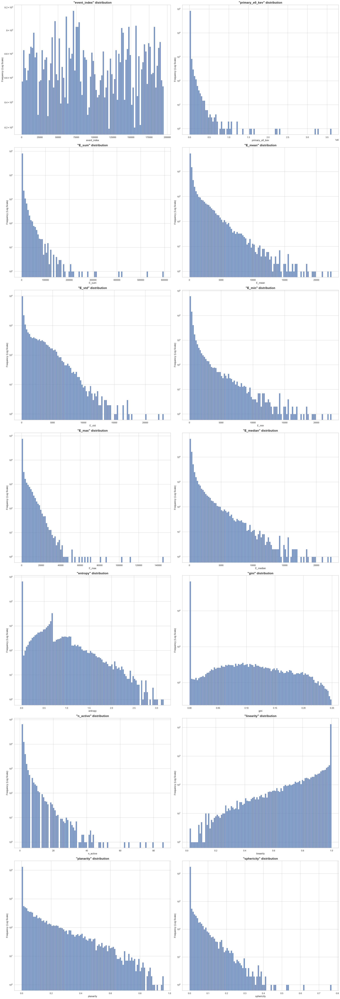

In [10]:
ncols = 2
nrows = (len(albedo_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(albedo_filtered.columns):

    sns.histplot(
        data=albedo_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

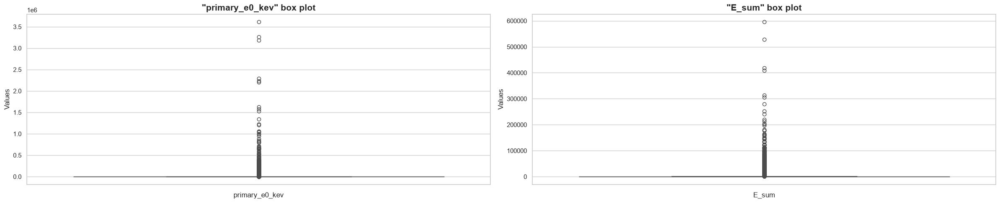

In [11]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=albedo_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    # axes[i].set_yscale("symlog")
    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

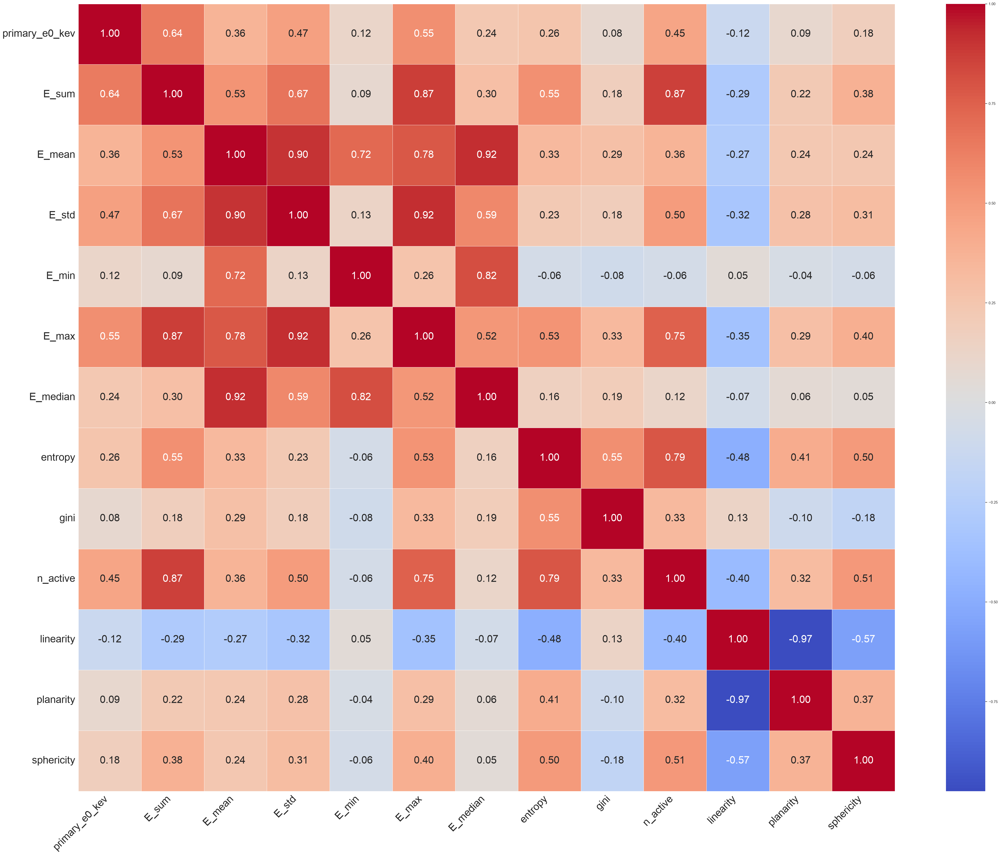

In [12]:
correlation_matrix = (albedo_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.2 - Atmospheric Neutrons

In [ ]:
url_atmosphericneutrons = url_bgdata + "AtmosphericNeutrons_20260917_161622" + url_ds

atm_neutrons = pd.read_csv(url_atmosphericneutrons, header=0)
print("Atmospheric Neutrons dataset shape:", atm_neutrons.shape)

Atmospheric Neutrons dataset shape: (2161, 53)


In [14]:
atm_neutrons.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,2161.000000,2161,2.161000e+03,2161.000000,2161.000000,2161.000000,797.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,450.000000,450.000000,2161.000000,2161.000000,2161.000000,2161.0,2161.000000,2161.000000,2161.0,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2.161000e+03,2161.000000,797.000000,7.970000e+02,797.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.000000,2161.0,0.0,6.460000e+02,396.000000,0.0,2161.000000,2161.000000,2161.000000,2161.000000
unique,NaN,1255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,8,0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4780.674225,NaN,4.743167e+04,2.200370,5237.709080,1644.620044,3030.637250,965.105152,3633.650033,1294.008268,1020.810385,1105.667557,1785.340533,2510.885837,2917.303718,3470.241929,679.672976,302.323750,0.721715,-0.847921,0.294989,0.040263,2.200370,1.0,0.874890,0.981736,1.0,4.437479,4.448940,4.361618,0.577353,1.150053,1.071746e-01,0.019156,0.884326,9.508538e-02,0.020589,0.002046,-0.002939,0.017277,0.994447,1.005090,1.029616,2.200370,1.0,NaN,3.608746e-01,0.890499,NaN,0.372513,0.447215,0.255437,2.732100
std,2789.081924,NaN,4.943072e+05,2.863584,24497.488128,5324.978906,6521.830502,4688.051129,12750.177454,5036.231886,4706.335719,4773.372626,5871.139551,7505.279039,8671.870506,11516.509164,3007.908066,1676.793500,0.792340,2.780683,0.478494,0.064357,2.863584,0.0,0.202168,0.065159,0.0,2.844670,2.800264,2.839545,0.971331,2.880687,4.093719e-01,0.098523,0.184726,1.565306e-01,0.055226,0.326217,0.329144,0.329660,1.899553,1.906002,1.932196,2.863584,0.0,NaN,3.560380e-01,0.115860,NaN,0.846323,0.972967,1.338704,5.562843
min,3.000000,NaN,1.823120e+01,1.000000,15.110590,15.100585,0.097531,15.004240,15.110590,15.100585,15.045413,15.066102,15.110590,15.110590,15.110590,15.110590,0.000000,0.000000,-0.695607,-2.437361,-0.000000,0.000000,1.000000,1.0,0.186618,0.420735,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.085909,0.000000e+00,0.000000,-0.999027,-0.996745,-0.993370,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-9.309075e-17,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,2353.000000,NaN,7.177790e+02,1.000000,63.885790,52.690480,64.035787,34.541320,57.358630,51.887230,40.833640,45.618540,54.653890,56.748995,57.071060,57.241620,0.000000,0.000000,0.278028,-2.333333,0.000000,0.000000,1.000000,1.0,0.768170,1.000000,1.0,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000e+00,0.000000,0.832344,1.397407e-18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,NaN,2.397574e-16,0.750000,NaN,0.000000,0.000000,0.000000,0.000000
50%,4719.000000,NaN,2.907046e+03,1.000000,200.284990,155.100000,331.895749,80.701690,177.174860,139.067930,95.362270,116.763700,166.522640,175.016760,175.271760,177.045280,0.000000,0.000000,0.505933,-1.763195,0.000000,0.000000,1.000000,1.0,1.000000,1.000000,1.0,4.000000,4.402365,4.029786,0.000000,0.000000,0.000000e+00,0.000000,0.9

In [15]:
print(f"\n\nThe features of the Atmospheric Neutrons dataset before filtering are {atm_neutrons.shape}:")
print(atm_neutrons.columns.tolist())

atm_neutrons_filtered = atm_neutrons[columns_to_analyze]
print(f"\n\nThe features of the Atmospheric Neutrons dataset after filtering are {atm_neutrons_filtered.shape}:")
print(atm_neutrons_filtered.columns.tolist())



The features of the Atmospheric Neutrons dataset before filtering are (2161, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Atmospheric Neutrons dataset after filtering are (2161, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [16]:
atm_neutrons_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,3,2612.376,52.10290,52.102900,NaN,52.10290,52.10290,52.102900,-0.000000,0.000000,1,NaN,NaN,NaN
1,8,362.943,43.95928,43.959280,NaN,43.95928,43.95928,43.959280,-0.000000,0.000000,1,NaN,NaN,NaN
2,20,3758.171,785.16932,785.169320,NaN,785.16932,785.16932,785.169320,-0.000000,0.000000,1,NaN,NaN,NaN
3,21,4541.022,495.57679,247.788395,126.077528,158.63812,336.93867,247.788395,0.626951,0.089946,2,1.0,3.596632e-17,0.0
4,23,874.754,100.08855,100.088550,NaN,100.08855,100.08855,100.088550,-0.000000,0.000000,1,NaN,NaN,NaN


In [17]:
print(f"\nThe number of missing values in each column of the filtered Atmospheric Neutrons dataset is:")
atm_neutrons_filtered.isnull().sum()


The number of missing values in each column of the filtered Atmospheric Neutrons dataset is:


event_index          0
primary_e0_kev       0
E_sum                0
E_mean               0
E_std             1364
E_min                0
E_max                0
E_median             0
entropy              0
gini                 0
n_active             0
linearity         1364
planarity         1364
sphericity        1364
dtype: int64

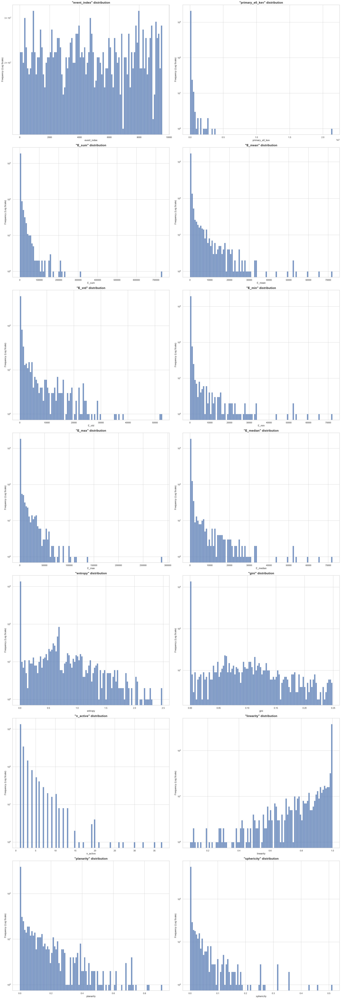

In [18]:
ncols = 2
nrows = (len(atm_neutrons_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(atm_neutrons_filtered.columns):

    sns.histplot(
        data=atm_neutrons_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

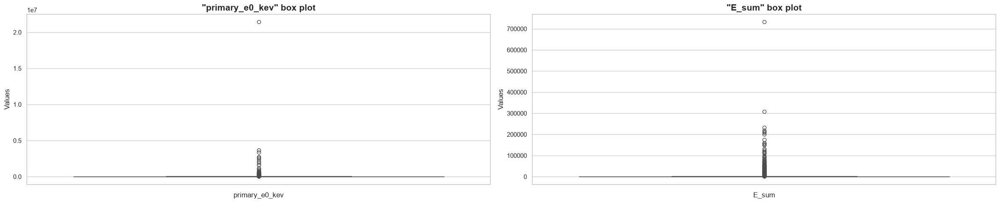

In [19]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=atm_neutrons_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

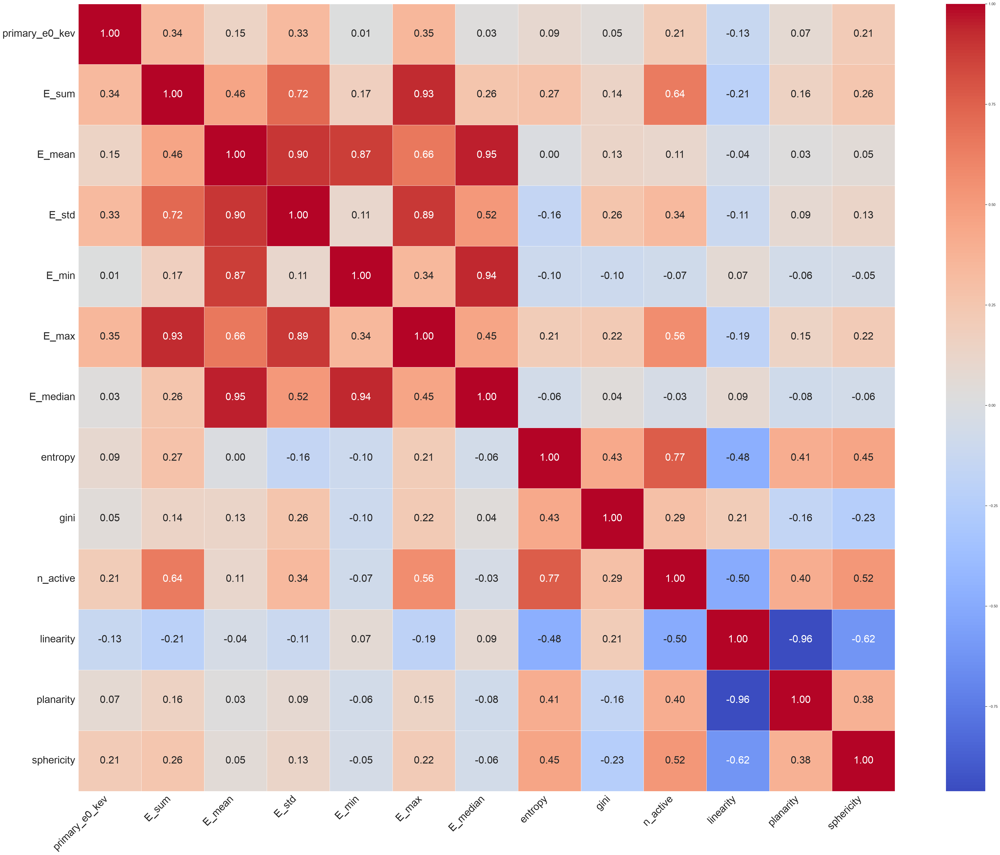

In [20]:
correlation_matrix = (atm_neutrons_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.3 - Cosmic Photons

In [21]:
url_cosmicphotons = url_bgdata + "CosmicPhotons_20260917_161711" + url_ds

cosmic_pht = pd.read_csv(url_cosmicphotons, header=0)
print("Cosmic Photons dataset shape:", cosmic_pht.shape)

Cosmic Photons dataset shape: (152860, 53)


In [22]:
cosmic_pht.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,152860.000000,152860,152860.000000,152860.000000,152860.000000,152860.000000,15384.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,1925.000000,1925.000000,152860.000000,152860.000000,152860.000000,152860.0,152860.000000,152860.000000,152860.0,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,15384.000000,1.538400e+04,15384.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.000000,152860.0,0.0,6.625000e+03,1313.000000,0.0,152860.000000,152860.000000,152860.000000,152860.000000
unique,NaN,9888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,9,9]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,145352.302545,NaN,231.236167,1.118082,195.295871,166.644821,131.641676,157.142840,179.449443,165.088411,158.682970,161.002292,170.971888,175.752239,177.544105,179.067636,9.969597,7.460604,0.183998,-2.189183,0.062361,0.010155,1.118082,1.0,0.968425,0.999752,1.0,4.485150,4.445061,5.174261,0.092068,0.119160,0.002989,0.000135,0.978871,2.027466e-02,0.000854,-0.000512,-0.000450,-0.003809,0.101838,0.100962,0.104763,1.118082,1.0,NaN,1.021865e-01,0.910184,NaN,0.068658,0.083895,0.002192,0.231929
std,83855.186349,NaN,2705.006742,0.410773,669.984098,170.479386,399.982341,144.654671,327.722862,160.761315,145.198024,148.433017,195.879049,249.881432,282.776388,318.089738,108.682053,65.366314,0.351921,0.501880,0.195573,0.035237,0.410773,0.0,0.102742,0.006197,0.0,3.274371,3.210320,3.137585,0.337355,0.728590,0.047772,0.006408,0.081942,7.883789e-02,0.010558,0.119810,0.120388,0.121839,0.481503,0.472265,0.476386,0.410773,0.0,NaN,2.246633e-01,0.120570,NaN,0.266746,0.330493,0.105280,0.908190
min,3.000000,NaN,100.000000,1.000000,15.006160,15.006160,0.003062,15.001220,15.006160,15.006160,15.006160,15.006160,15.006160,15.006160,15.006160,15.006160,0.000000,0.000000,-0.633566,-2.436467,-0.000000,0.000000,1.000000,1.0,0.173425,0.493562,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.058638,0.000000e+00,0.000000,-0.991659,-0.996019,-0.994022,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-1.057477e-16,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,72898.750000,NaN,116.288750,1.000000,112.838243,109.631618,26.008498,107.612810,111.064535,109.551992,107.854852,108.394215,110.434360,110.842909,110.956575,111.044395,0.000000,0.000000,-0.065808,-2.333333,-0.000000,0.000000,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,NaN,1.451502e-16,0.750000,NaN,0.000000,0.000000,0.000000,0.000000
50%,145456.000000,NaN,142.965000,1.000000,138.189125,133.268865,57.801281,130.592795,135.906685,133.174175,130.925940,131.563220,134.797975,135.513275,135.713020,135.861845,0.000000,0.000000,0.248038,-2.333333,-0.000000,0.000000,1.000000,1.0,1.000000,1.000000,1.0,4.369182,4.

In [23]:
print(f"\n\nThe features of the Cosmic Photons dataset before filtering are {cosmic_pht.shape}:")
print(cosmic_pht.columns.tolist())

cosmic_pht_filtered = cosmic_pht[columns_to_analyze]
print(f"\n\nThe features of the Cosmic Photons dataset after filtering are {cosmic_pht_filtered.shape}:")
print(cosmic_pht_filtered.columns.tolist())



The features of the Cosmic Photons dataset before filtering are (152860, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Cosmic Photons dataset after filtering are (152860, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [24]:
cosmic_pht_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,3,128.027,128.02683,128.026830,NaN,128.02683,128.02683,128.026830,-0.000000,0.000000,1,NaN,NaN,NaN
1,4,220.101,177.74452,177.744520,NaN,177.74452,177.74452,177.744520,-0.000000,0.000000,1,NaN,NaN,NaN
2,5,102.358,102.35814,102.358140,NaN,102.35814,102.35814,102.358140,-0.000000,0.000000,1,NaN,NaN,NaN
3,12,125.085,125.08471,62.542355,28.547817,42.35600,82.72871,62.542355,0.640115,0.080691,2,1.0,0.0,0.0
4,13,220.165,220.16490,220.164900,NaN,220.16490,220.16490,220.164900,-0.000000,0.000000,1,NaN,NaN,NaN


In [25]:
print(f"\nThe number of missing values in each column of the filtered Cosmic Photons dataset is:")
cosmic_pht_filtered.isnull().sum()


The number of missing values in each column of the filtered Cosmic Photons dataset is:


event_index            0
primary_e0_kev         0
E_sum                  0
E_mean                 0
E_std             137476
E_min                  0
E_max                  0
E_median               0
entropy                0
gini                   0
n_active               0
linearity         137476
planarity         137476
sphericity        137476
dtype: int64

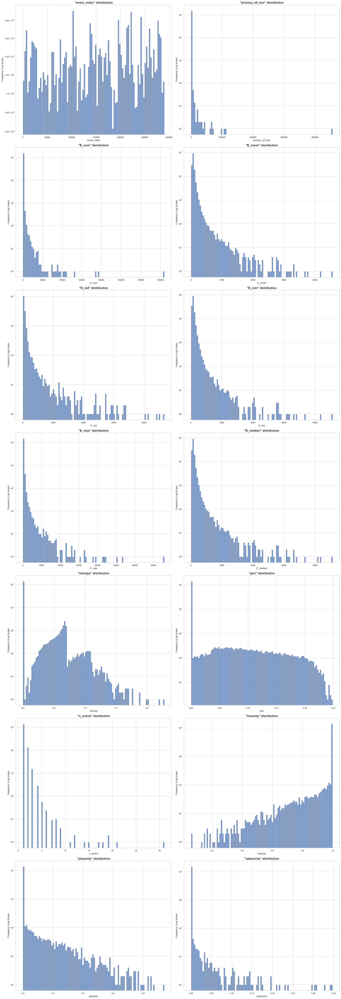

In [26]:
ncols = 2
nrows = (len(cosmic_pht_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(cosmic_pht_filtered.columns):

    sns.histplot(
        data=cosmic_pht_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

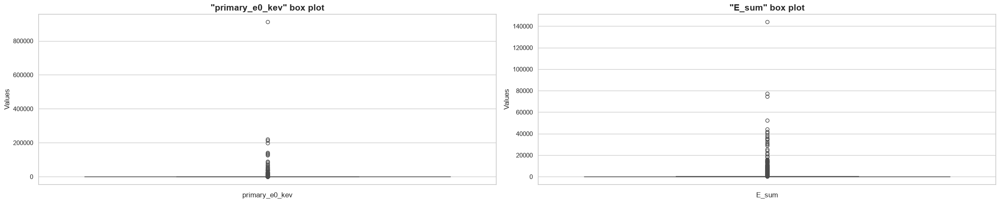

In [27]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=cosmic_pht_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

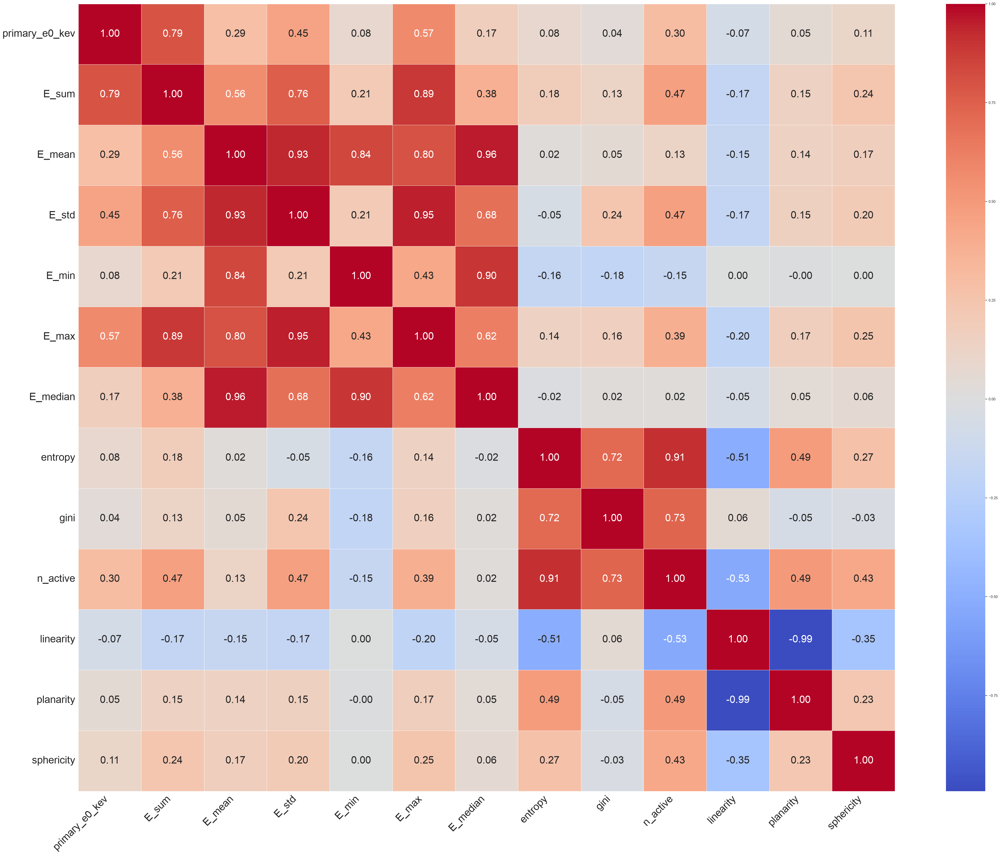

In [28]:
correlation_matrix = (cosmic_pht_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.4 - Primary Alphas

In [29]:
url_primaryalpha = url_bgdata + "PrimaryAlphas_20260917_163423" + url_ds

prim_alphas = pd.read_csv(url_primaryalpha, header=0)
print("Primary Alphas dataset shape:", prim_alphas.shape)

Primary Alphas dataset shape: (2781, 53)


In [30]:
prim_alphas.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,2781.000000,2781,2.781000e+03,2781.000000,2.781000e+03,2781.000000,2157.000000,2781.000000,2.781000e+03,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2.781000e+03,2781.000000,2781.000000,1870.000000,1870.000000,2781.000000,2781.000000,2781.000000,2781.0,2781.000000,2781.000000,2781.0,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2157.000000,2157.000000,2.157000e+03,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.000000,2781.0,0.0,1.886000e+03,1771.000000,0.0,2781.000000,2781.000000,2781.000000,2781.000000
unique,NaN,2406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,9,9]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2269.589716,NaN,4.525402e+07,13.891766,2.434208e+05,14846.174242,21120.607476,3882.905288,7.767122e+04,10939.459147,4684.679740,6247.091583,19402.652403,27159.656624,32262.776655,5.154666e+04,13155.560820,4957.320353,1.259979,5.110067,1.145879,0.056046,13.891766,1.0,0.562937,0.835376,1.0,4.510306,4.586659,4.519270,1.535876,3.516216,0.289584,0.102515,0.899379,0.070799,2.982184e-02,0.009233,0.004024,-0.003100,3.215031,3.166846,2.898598,13.891766,1.0,NaN,8.130587e-01,0.952639,NaN,2.674218,2.917342,8.128731,17.648465
std,1311.709726,NaN,1.658417e+08,30.557520,6.747059e+05,10608.285367,23473.399147,8668.775738,1.931181e+05,11306.736217,8821.302141,9455.626828,13656.645864,19123.698929,25832.987988,8.256569e+04,11823.514975,5579.643751,2.150759,20.494313,0.916355,0.055408,30.557520,0.0,0.302523,0.201242,0.0,2.844488,2.800716,2.899400,1.244972,4.115805,0.687300,0.284764,0.163143,0.121951,6.726587e-02,0.373975,0.375549,0.413654,3.177224,3.136383,3.062620,30.557520,0.0,NaN,3.688575e-01,0.066740,NaN,3.279259,3.259089,25.462230,36.185626
min,3.000000,NaN,1.823116e+01,1.000000,1.823116e+01,18.231160,0.488300,15.005720,1.823116e+01,18.231160,18.231160,18.231160,18.231160,18.231160,18.231160,1.823116e+01,0.000000,0.000000,-1.420249,-2.436574,-0.000000,0.000000,1.000000,1.0,0.067634,0.188182,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.067443,0.000000,0.000000e+00,-0.999714,-0.999214,-0.999603,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-9.309075e-17,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,1149.000000,NaN,1.865284e+07,2.000000,2.066423e+04,8426.219513,12448.655015,43.206070,1.768104e+04,1456.439690,131.816267,290.579270,8380.642430,15255.422984,17086.378930,1.753086e+04,195.857320,105.641950,0.111443,-2.004264,0.227568,0.006583,2.000000,1.0,0.295328,0.672752,1.0,2.001726,2.115639,2.000000,0.338500,0.111532,0.000000,0.000000,0.889895,0.004465,8.585445e-32,-0.127091,-0.131006,-0.158776,0.000000,0.000000,0.000000,2.000000,1.0,NaN,5.849625e-01,0.943265,NaN,0.000000,0.000000,0.000000,1.000000
50%,2275.000000,NaN,2.691291e+07,5.000000,8.284593e+04,14609.355674,16170.500590,168.900860,3.715784e+04,6870.959460,385.750030,1201.699140,19957.585900,30781.006033,34421.531493,3.679863e+04,12453.621625,3021.587665,0.490562,-1.562197,1.136277,0.045967,5.000000,1.0,0.

In [31]:
print(f"\n\nThe features of the Primary Alphas dataset before filtering are {prim_alphas.shape}:")
print(prim_alphas.columns.tolist())

prim_alphas_filtered = prim_alphas[columns_to_analyze]
print(f"\n\nThe features of the Primary Alphas dataset after filtering are {prim_alphas_filtered.shape}:")
print(prim_alphas_filtered.columns.tolist())



The features of the Primary Alphas dataset before filtering are (2781, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Primary Alphas dataset after filtering are (2781, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [32]:
prim_alphas_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,3,2.598804e+07,41807.87029,41807.870290,NaN,41807.87029,41807.87029,41807.87029,-0.000000,2.220446e-16,1,NaN,NaN,NaN
1,4,5.128637e+07,213676.00804,17806.334003,18243.599856,43.06030,43183.65804,11172.74882,1.917049,4.475293e-02,12,0.983075,0.012226,0.004699
2,5,1.668240e+07,190455.03368,17314.093971,10538.929926,138.36704,34239.79113,15984.54524,2.170137,2.921405e-02,11,0.990668,0.002328,0.007004
3,6,2.016155e+07,61302.79490,30651.397450,2735.895061,28716.82750,32585.96740,30651.39745,0.691154,1.577881e-02,2,1.000000,0.000000,0.000000
4,7,6.045241e+07,108126.02216,15446.574594,15567.301779,46.45534,34401.23056,10017.12135,1.421146,7.279675e-02,7,0.909954,0.080256,0.009790


In [33]:
print(f"\nThe number of missing values in each column of the filtered Primary Alphas dataset is:")
prim_alphas_filtered.isnull().sum()


The number of missing values in each column of the filtered Primary Alphas dataset is:


event_index         0
primary_e0_kev      0
E_sum               0
E_mean              0
E_std             624
E_min               0
E_max               0
E_median            0
entropy             0
gini                0
n_active            0
linearity         624
planarity         624
sphericity        624
dtype: int64

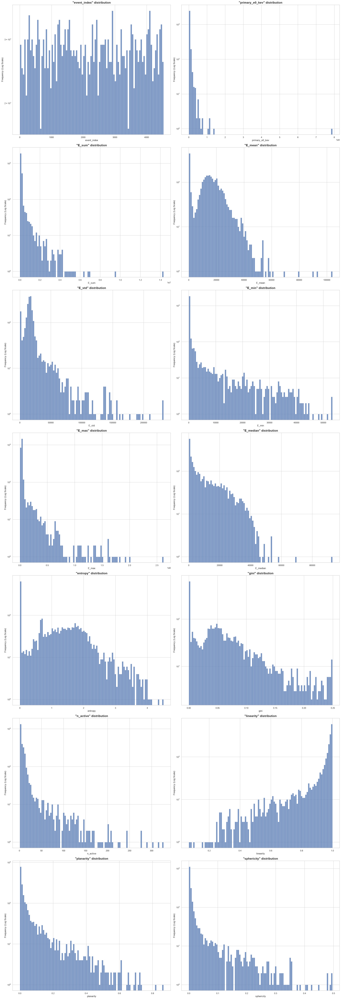

In [34]:
ncols = 2
nrows = (len(prim_alphas_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(prim_alphas_filtered.columns):

    sns.histplot(
        data=prim_alphas_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

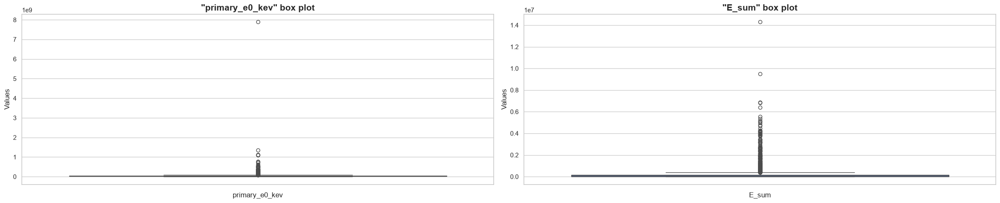

In [35]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=prim_alphas_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

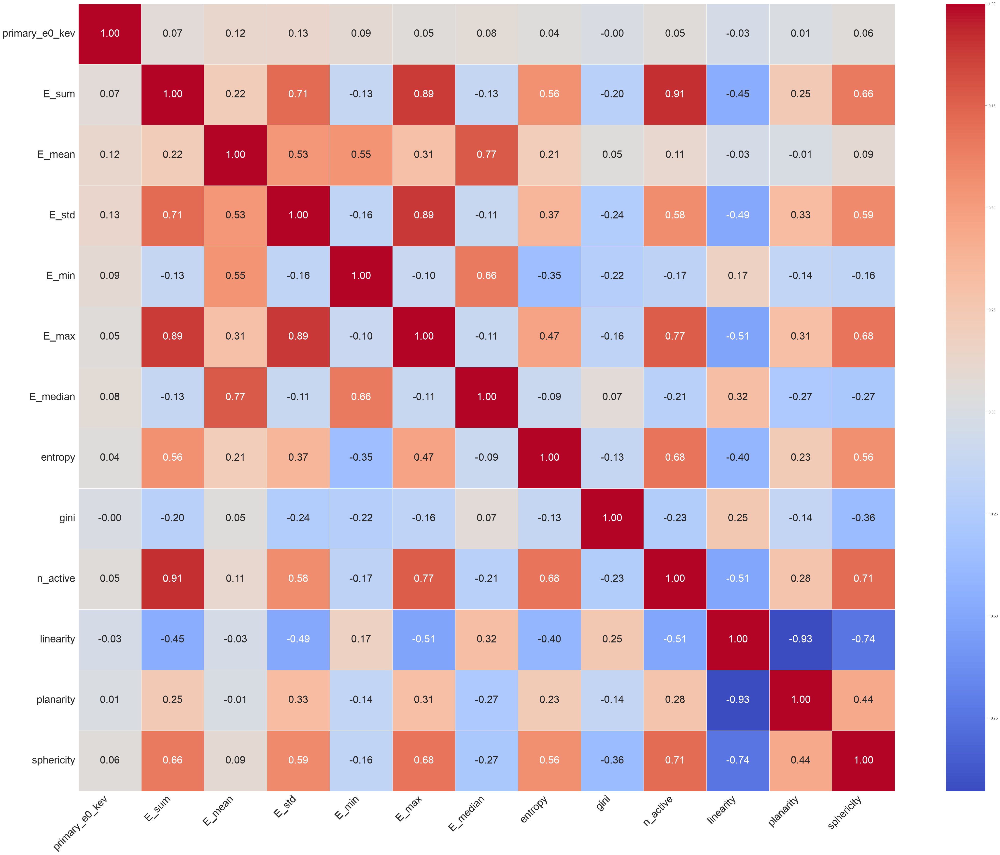

In [36]:
correlation_matrix = (prim_alphas_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.5 - Primary Electrons

In [37]:
url_primaryelectrons = url_bgdata + "PrimaryElectrons_20260917_163621" + url_ds

prim_electrons = pd.read_csv(url_primaryelectrons, header=0)
print("Primary Electrons dataset shape:", prim_electrons.shape)

Primary Electrons dataset shape: (148, 53)


In [38]:
prim_electrons.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,148.000000,148,1.480000e+02,148.000000,1.480000e+02,148.000000,123.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,115.000000,115.000000,148.000000,148.000000,148.000000,148.0,148.000000,148.000000,148.0,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,123.000000,123.000000,123.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.0,0.0,1.170000e+02,113.000000,0.0,148.000000,148.000000,148.000000,148.000000
unique,NaN,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[6,1,8]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,118.871622,NaN,1.661398e+07,27.121622,3.059141e+05,9462.290436,23226.951252,1176.656588,96645.319845,2785.899127,1346.433943,1640.920924,7717.313425,19954.641657,35873.197944,77693.621907,6076.392500,1407.950084,2.582705,9.625941,1.359134,0.050002,27.121622,1.0,0.550235,0.811471,1.0,4.717692,4.441475,4.300267,1.534381,2.942347,0.279909,0.119161,0.878140,0.075954,0.045906,0.039966,-0.010582,-0.087771,4.695946,4.682432,4.506757,27.121622,1.0,NaN,1.005430e+00,0.952006,NaN,4.398649,4.548501,18.297297,35.202748
std,66.443089,NaN,1.847488e+07,35.759002,4.593762e+05,7018.645477,19218.711868,3558.829618,125928.181268,4209.588528,3547.552408,3597.045573,7555.854296,18922.271898,33474.497871,93640.585324,7108.714595,2392.875273,1.857540,13.415563,0.931260,0.055561,35.759002,0.0,0.277018,0.188169,0.0,2.933888,3.021907,2.894183,0.996899,2.888024,0.301885,0.143021,0.127133,0.099764,0.046978,0.397842,0.467114,0.464968,3.357718,3.364555,3.419624,35.759002,0.0,NaN,4.088214e-01,0.061810,NaN,4.026680,4.014471,29.059746,43.400827
min,1.000000,NaN,3.451986e+01,1.000000,3.451986e+01,34.519860,49.771705,15.197720,34.519860,34.519860,34.519860,34.519860,34.519860,34.519860,34.519860,34.519860,0.000000,0.000000,-0.327278,-2.427442,-0.000000,0.000000,1.000000,1.0,0.127297,0.335617,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.325814,0.000000,0.000000,-0.996159,-0.996159,-0.998438,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-9.309075e-17,0.750000,NaN,0.000000,0.000000,0.000000,0.000000
25%,62.750000,NaN,9.672758e+06,3.000000,1.994292e+04,5333.582647,10186.270467,32.200450,11449.739228,510.998910,89.041384,213.058386,3531.716084,9405.641194,11139.255781,11371.235196,1962.782544,331.556745,0.982242,-0.769525,0.657989,0.010326,3.000000,1.0,0.342043,0.672972,1.0,2.110593,1.516584,1.804393,0.816609,0.485856,0.009059,0.000000,0.854195,0.018595,0.005019,-0.196915,-0.283497,-0.352789,1.000000,1.000000,1.000000,3.000000,1.0,NaN,7.075187e-01,0.943350,NaN,1.000000,1.000000,0.000000,4.605745
50%,120.500000,NaN,1.268870e+07,12.500000,1.007971e+05,8140.955237,17484.658110,48.688650,52838.093390,1027.693015,163.626846,287.869789,5911.203136,16275.811686,27786.288993,51022.672777,4522.785743,602.184947,2.271545,4.431755,1.412561,0.031054,12.500000,1.0,0.463284,0.851411,1.0,4.596113,4.516072,4.143558,1.678875,2.330579,0.206649,0.064249,0.914318,

In [39]:
print(f"\n\nThe features of the Primary Electrons dataset before filtering are {prim_electrons.shape}:")
print(prim_electrons.columns.tolist())

prim_electrons_filtered = prim_electrons[columns_to_analyze]
print(f"\n\nThe features of the Primary Electrons dataset after filtering are {prim_electrons_filtered.shape}:")
print(prim_electrons_filtered.columns.tolist())



The features of the Primary Electrons dataset before filtering are (148, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Primary Electrons dataset after filtering are (148, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [40]:
prim_electrons_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,1,5.968736e+06,72051.70364,6550.154876,9631.208675,43.06030,28812.91696,233.928940,1.457674,0.062478,11,0.460861,0.297306,0.241833
1,2,1.575940e+07,24298.80485,6074.701213,3583.379543,2564.26087,10304.49838,5715.022800,1.252313,0.070047,4,0.991727,0.008273,0.000000
2,3,1.133941e+07,10049.26201,3349.754003,1455.219326,1776.03906,4646.73817,3626.484780,1.030773,0.063481,3,0.965994,0.034006,0.000000
3,4,1.875905e+07,830764.37369,9890.052068,33368.691006,26.69350,184428.61698,407.272230,2.452554,0.010496,84,0.816243,0.142571,0.041186
4,5,6.263867e+06,98413.13713,6150.821071,7250.183874,123.64150,24333.33908,2672.358085,2.160374,0.036969,16,0.982250,0.015360,0.002390


In [41]:
print(f"\nThe number of missing values in each column of the filtered Primary Electrons dataset is:")
prim_electrons_filtered.isnull().sum()


The number of missing values in each column of the filtered Primary Electrons dataset is:


event_index        0
primary_e0_kev     0
E_sum              0
E_mean             0
E_std             25
E_min              0
E_max              0
E_median           0
entropy            0
gini               0
n_active           0
linearity         25
planarity         25
sphericity        25
dtype: int64

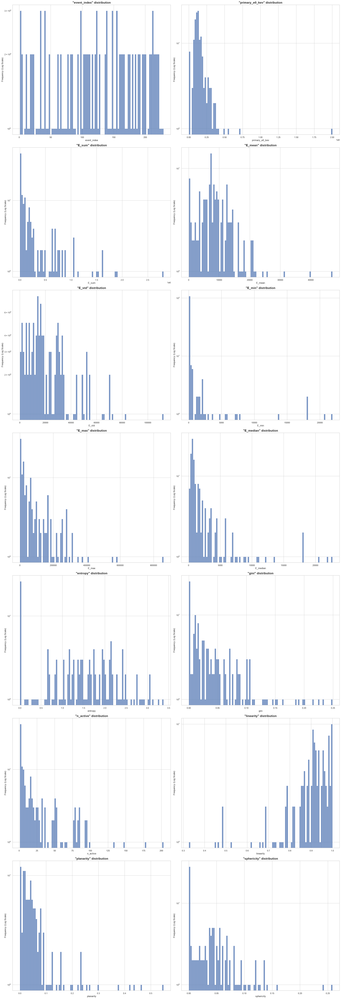

In [42]:
ncols = 2
nrows = (len(prim_electrons_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(prim_electrons_filtered.columns):

    sns.histplot(
        data=prim_electrons_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

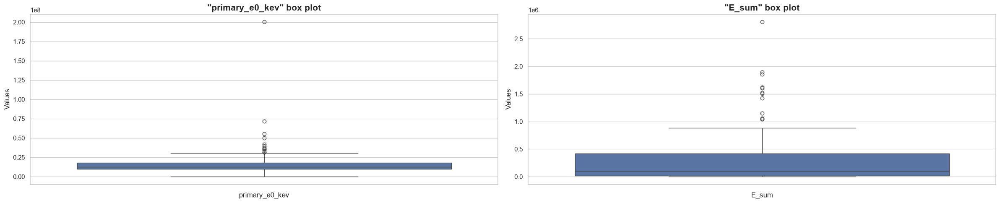

In [43]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=prim_electrons_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

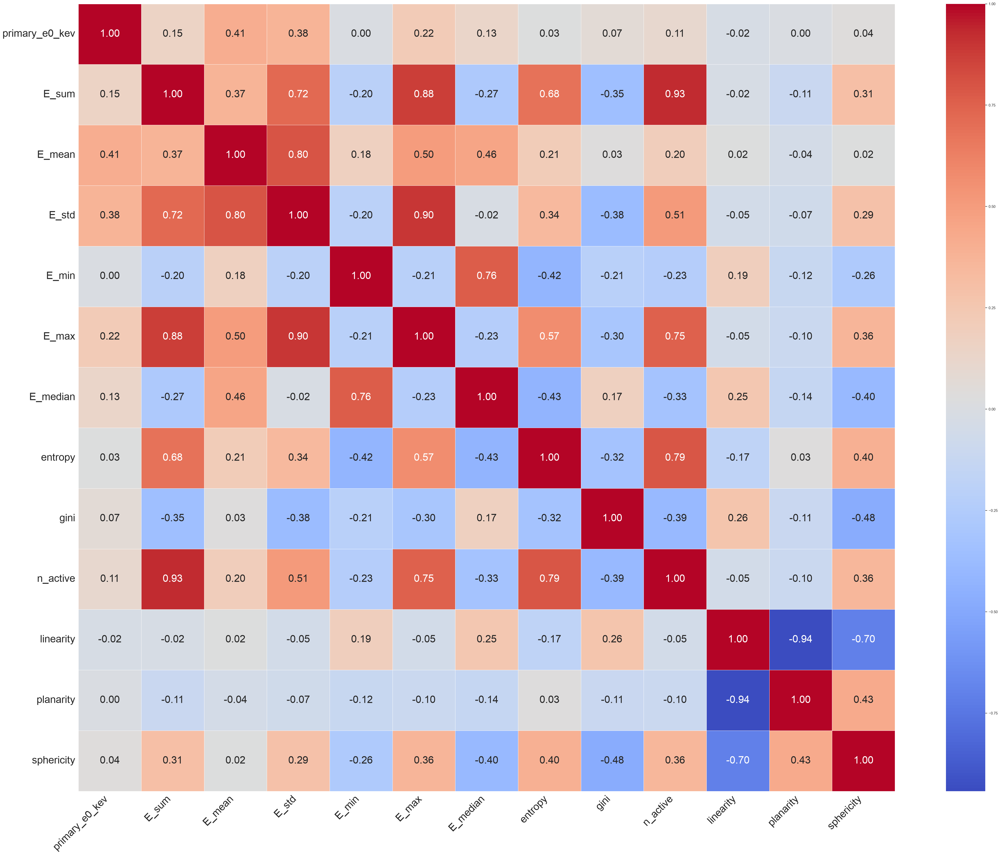

In [44]:
correlation_matrix = (prim_electrons_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.6 - Primary Positron

In [45]:
url_primarypositron = url_bgdata + "PrimaryPositrons_20260917_163647" + url_ds

prim_positrons = pd.read_csv(url_primarypositron, header=0)
print("Primary Positrons dataset shape:", prim_positrons.shape)

Primary Positrons dataset shape: (4, 53)


In [46]:
prim_positrons.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,4.000000,4,4.000000e+00,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000,1.000000,4.000000,4.000000e+00,4.000000,4.0,4.000000,4.000000,4.0,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000e+00,4.000000,3.000000,3.000000e+00,3.000000,4.000000,4.000000,4.000000,4.00,4.000000,4.00000,4.000000,4.0,0.0,2.000000e+00,1.000000,0.0,4.000000,4.000000,4.00,4.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[5,5,3];[5,4,2];[6,3,2];[5,3,2];[7,0,0];[6,3,1];[6,0,1];[6,2,2];[4,7,4];[5,3,1];[7,2,0];[6,4,1];[5,5,2];[7,2,6];[7,0,2];[4,5,3];[4,6,3];[4,8,4];[6,1,2];[5,3,0];[7,1,0];[7,1,2];[9,2,6];[6,3,3];[3,2,2];[4,4,2];[5,1,1];[5,6,2];[5,7,4];[5,1,2];[4,1,2];[6,0,3];[5,4,0];[6,5,2];[8,3,5];[7,4,1];[5,4,1];[6,3,4];[9,1,0];[7,0,6];[6,0,4];[4,8,5];[4,0,3];[5,1,0];[7,6,4];[4,3,3];[6,2,4];[2,2,8];[9,6,1];[8,4,0];[9,3,6];[6,4,0];[7,6,5];[7,0,4];[6,2,6];[8,1,1];[2,2,1];[6,6,3];[7,0,7];[4,3,1];[9,6,0];[5,5,6];[2,6,6];[3,8,5];[6,5,4];[3,4,3];[8,2,6];[8,2,2];[2,3,3];[8,5,2];[4,4,6];[5,5,1];[7,4,3];[9,1,1];[8,3,2];[8,3,4];[8,6,1];[4,3,4];[9,2,5];[7,7,0];[2,5,4];[6,1,5];[4,2,0];[8,1,3]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.500000,NaN,1.189586e+07,22.250000,199447.699942,4399.772167,10696.917583,668.452670,38286.542203,2217.899482,973.196515,1423.580464,4297.000031,8909.593129,16728.640833,31834.868307,2873.419566,1523.674660,3.621423,13.416489,0.876199,9.251061e-02,22.250000,1.0,0.724503,0.860001,1.0,5.381917,4.953802,5.008163,0.835579,1.289040,2.065843e-01,0.084304,0.936813,3.740105e-02,0.025786,-0.027423,-0.150329,0.136302,1.75,2.500000,2.25000,22.250000,1.0,NaN,8.211032e-01,0.986668,NaN,2.500000,2.872022,16.75,25.951392
std,2.081666,NaN,6.494305e+06,41.169366,388864.238725,3594.280635,11946.411608,722.336852,67394.560355,1828.827332,602.323995,919.460622,2765.972377,9803.713007,24784.013910,54585.134221,2856.799872,2159.893153,NaN,NaN,1.348641,1.139569e-01,41.169366,0.0,0.384930,0.279998,0.0,3.859836,2.190374,4.677864,1.084274,2.079578,4.131686e-01,0.168609,0.109443,6.478051e-02,0.044662,0.054846,0.218359,0.596549,3.50,3.785939,3.86221,41.169366,0.0,NaN,1.161215e+00,NaN,NaN,4.358899,5.099214,33.50,49.909462
min,1.000000,NaN,6.044554e+06,1.000000,1492.664400,1492.664400,1285.493958,17.135540,1492.664400,590.622515,111.250864,225.496580,1492.664400,1492.664400,1492.664400,1492.664400,0.000000,0.000000,3.621423,13.416489,-0.000000,2.220446e-16,1.000000,1.0,0.177893,0.440005,1.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.810440,0.000000e+00,0.000000,-0.109692,-0.462903,-0.432130,0.00,0.000000,0.00000,1.000000,1.0,NaN,1.451502e-16,0.986668,NaN,0.000000,0.000000,0.00,0.000000
25%,2.500000,NaN,8.056998e+06,1.750000,3318.645427,1845.905764,3976.980864,86.288398,2527.641885,1267.153929,817.115045,1175.872445,2186.773824,2391.294661,2459.468273,2514.007163,681.736121,352.798774,3.621423,13.416489,0.046525,7.486678e-03,1.750000,1.0,0.593062,0.860001,1.0,4.145750,3.208584

In [47]:
print(f"\n\nThe features of the Primary Positrons dataset before filtering are {prim_positrons.shape}:")
print(prim_positrons.columns.tolist())

prim_positrons_filtered = prim_positrons[columns_to_analyze]
print(f"\n\nThe features of the Primary Positrons dataset after filtering are {prim_positrons_filtered.shape}:")
print(prim_positrons_filtered.columns.tolist())



The features of the Primary Positrons dataset before filtering are (4, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Primary Positrons dataset after filtering are (4, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [48]:
prim_positrons_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,1,6.044554e+06,782721.51334,9318.113254,24136.791022,17.13554,139240.89312,590.622515,2.860952,9.982238e-03,84,0.81044,1.122031e-01,0.077357
1,3,1.184597e+07,9649.31626,4824.658130,6668.467770,109.33935,9539.97691,4824.658130,0.062033,2.443343e-01,2,1.00000,0.000000e+00,0.000000
2,4,2.096510e+07,3927.30577,1963.652885,1285.493958,1054.67139,2872.63438,1963.652885,0.581810,1.157258e-01,2,1.00000,1.003997e-30,0.000000
3,6,8.727812e+06,1492.66440,1492.664400,NaN,1492.66440,1492.66440,1492.664400,-0.000000,2.220446e-16,1,NaN,NaN,NaN


In [49]:
print(f"\nThe number of missing values in each column of the filtered Primary Positrons dataset is:")
prim_positrons_filtered.isnull().sum()


The number of missing values in each column of the filtered Primary Positrons dataset is:


event_index       0
primary_e0_kev    0
E_sum             0
E_mean            0
E_std             1
E_min             0
E_max             0
E_median          0
entropy           0
gini              0
n_active          0
linearity         1
planarity         1
sphericity        1
dtype: int64

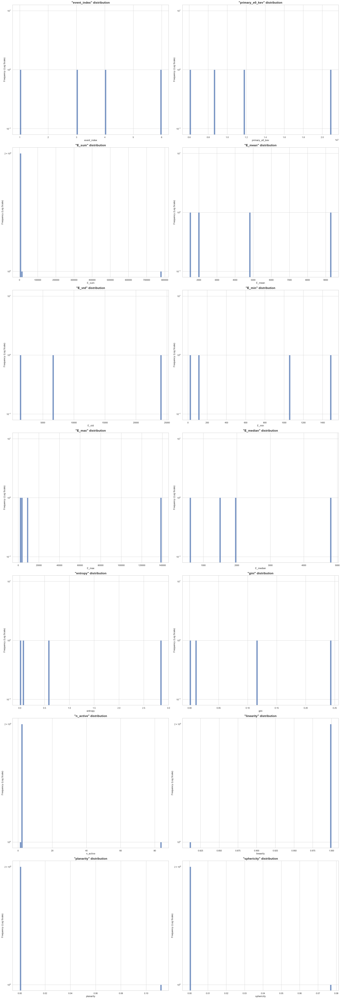

In [50]:
ncols = 2
nrows = (len(prim_positrons_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(prim_positrons_filtered.columns):

    sns.histplot(
        data=prim_positrons_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

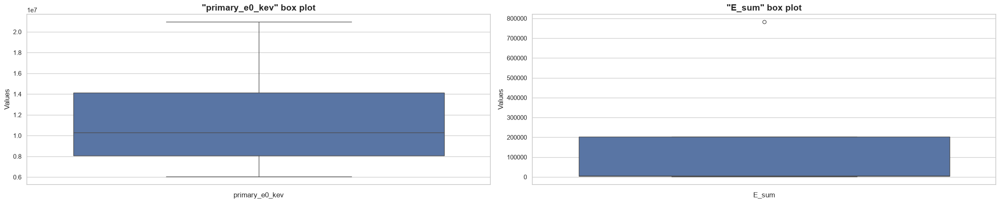

In [51]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=prim_positrons_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

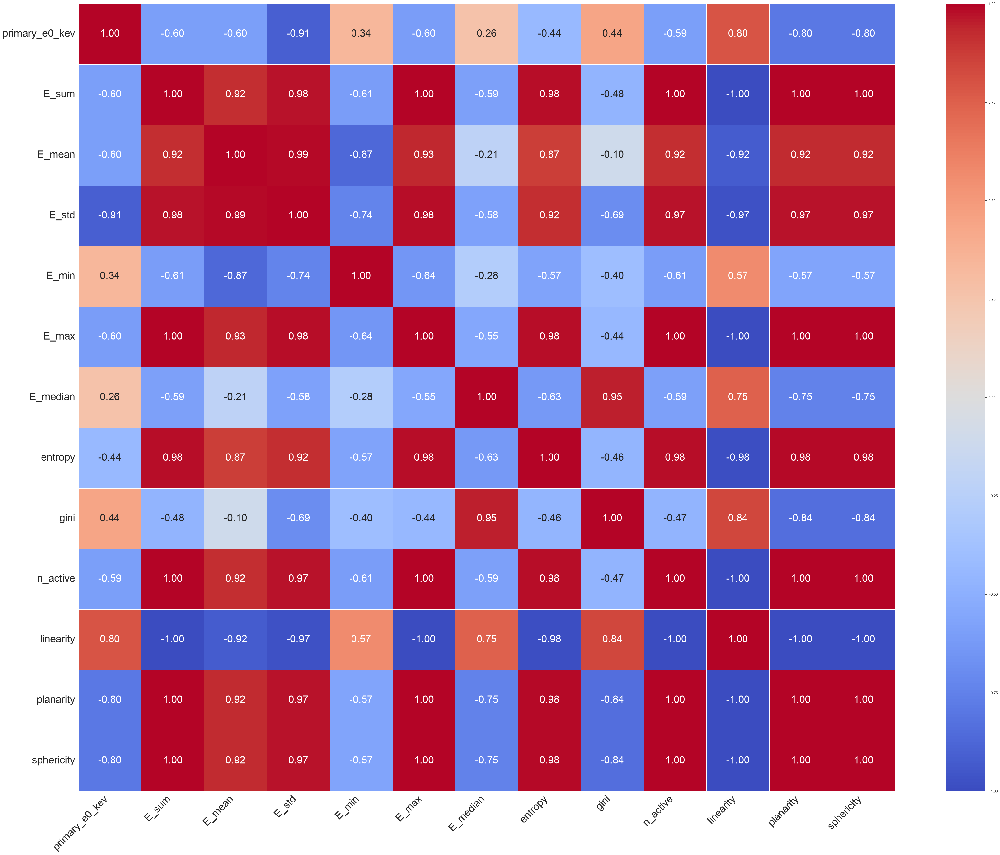

In [52]:
correlation_matrix = (prim_positrons_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.7 - Primary Protons

In [53]:
url_primaryprotons = url_bgdata + "PrimaryProtons_20260917_163703" + url_ds

prim_protons = pd.read_csv(url_primaryprotons, header=0)
print("Primary Protons dataset shape:", prim_protons    .shape)

Primary Protons dataset shape: (18461, 53)


In [54]:
prim_protons.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,18461.000000,18461,1.846100e+04,18461.000000,1.846100e+04,18461.000000,14886.000000,18461.000000,1.846100e+04,18461.000000,18461.000000,18461.000000,18461.000000,18461.000000,18461.000000,1.846100e+04,18461.000000,18461.000000,12751.000000,12751.000000,18461.000000,18461.000000,18461.000000,18461.0,18461.000000,18461.000000,18461.0,18461.000000,18461.000000,18461.000000,18461.000000,18461.000000,18461.000000,1.846100e+04,14886.000000,14886.000000,14886.000000,18461.000000,18461.000000,18461.000000,18461.000000,18461.000000,18461.000000,18461.000000,18461.0,0.0,1.301600e+04,12066.000000,0.0,18461.000000,18461.000000,18461.000000,18461.000000
unique,NaN,14448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,9,9]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,15403.170305,NaN,2.118748e+07,9.416066,9.501339e+04,6201.177046,8481.088747,1768.127592,3.159402e+04,4626.121657,2208.055045,2962.658408,7174.154954,10624.868306,13919.211082,2.371036e+04,4211.496546,1828.496628,0.749287,1.652904,1.165885,0.053672,9.416066,1.0,0.535375,0.830767,1.0,4.468546,4.477060,4.468494,1.623441,3.811233,0.232214,7.067320e-02,0.920419,0.059640,0.019940,-0.002662,-0.001715,0.004428,2.955745,3.027788,2.606251,9.416066,1.0,NaN,7.199070e-01,0.952711,NaN,2.282487,2.592469,4.398949,12.158827
std,8894.994895,NaN,7.552609e+07,18.916254,2.813105e+05,5856.140088,15561.959515,3594.094137,8.674234e+04,3961.888947,3589.632208,3703.424464,5323.194860,12018.376664,21377.761002,5.379040e+04,4553.827084,1824.358498,1.591590,11.152551,0.825830,0.049975,18.916254,0.0,0.291223,0.194397,0.0,2.876255,2.783593,2.881501,1.215993,4.161395,0.583315,2.213777e-01,0.142315,0.110702,0.052658,0.341992,0.343756,0.361362,3.002192,3.000440,2.880096,18.916254,0.0,NaN,3.400255e-01,0.069090,NaN,2.683522,2.799411,14.838598,23.759994
min,1.000000,NaN,1.612849e+01,1.000000,1.612849e+01,16.128490,1.309548,15.005380,1.612849e+01,16.128490,16.128490,16.128490,16.128490,16.128490,16.128490,1.612849e+01,0.000000,0.000000,-1.867664,-2.437286,-0.000000,0.000000,1.000000,1.0,0.055853,0.151471,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.013036,0.000000,0.000000,-0.999210,-0.998870,-0.999361,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-9.309075e-17,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,7675.000000,NaN,1.083282e+07,2.000000,9.360880e+03,3815.919815,2885.891095,96.600660,6.845077e+03,2182.648460,247.554590,597.432085,4909.633120,6299.375514,6630.073282,6.791607e+03,643.743487,282.322460,-0.087512,-2.041539,0.541224,0.015035,2.000000,1.0,0.287163,0.675470,1.0,2.000000,2.019462,1.991782,0.492546,0.237458,0.000000,0.000000e+00,0.926998,0.003705,0.000000,-0.145078,-0.141075,-0.118143,0.000000,0.000000,0.000000,2.000000,1.0,NaN,5.169925e-01,0.938564,NaN,0.000000,0.000000,0.000000,1.414214
50%,15445.000000,NaN,1.441900e+07,5.000000,2.472796e+04,5410.760876,3942.811822,510.998910,9.749405e+03,4497.686200,1245.025140,2269.001618,7382.078325,8863.041720,9364.697410,9.667440e+03,3619.449273,1577.021980,0.281422,-1.682659,1.2

In [55]:
print(f"\n\nThe features of the Primary Protons dataset before filtering are {prim_protons.shape}:")
print(prim_protons.columns.tolist())
    
prim_protons_filtered = prim_protons[columns_to_analyze]
print(f"\n\nThe features of the Primary Protons dataset after filtering are {prim_protons_filtered.shape}:")
print(prim_protons_filtered.columns.tolist())



The features of the Primary Protons dataset before filtering are (18461, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Primary Protons dataset after filtering are (18461, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [56]:
prim_protons_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,1,8.686081e+06,142985.79397,3404.423666,5358.901632,15.55594,21709.28630,541.168205,2.782253,0.016965,42,0.846936,0.09728,0.055784
1,2,3.895589e+02,389.55891,194.779455,109.106951,117.62919,271.92972,194.779455,0.612512,0.099023,2,1.000000,0.00000,0.000000
2,3,7.607834e+01,76.07834,76.078340,NaN,76.07834,76.07834,76.078340,-0.000000,0.000000,1,NaN,NaN,NaN
3,4,5.368102e+01,53.68102,53.681020,NaN,53.68102,53.68102,53.681020,-0.000000,0.000000,1,NaN,NaN,NaN
4,5,4.153048e+01,41.53048,41.530480,NaN,41.53048,41.53048,41.530480,-0.000000,0.000000,1,NaN,NaN,NaN


In [57]:
print(f"\nThe number of missing values in each column of the filtered Primary Protons dataset is:")
prim_protons_filtered.isnull().sum()


The number of missing values in each column of the filtered Primary Protons dataset is:


event_index          0
primary_e0_kev       0
E_sum                0
E_mean               0
E_std             3575
E_min                0
E_max                0
E_median             0
entropy              0
gini                 0
n_active             0
linearity         3575
planarity         3575
sphericity        3575
dtype: int64

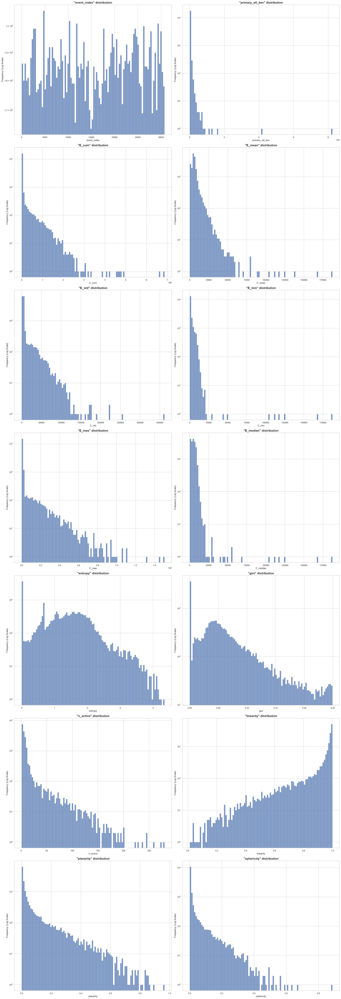

In [58]:
ncols = 2
nrows = (len(prim_protons_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(prim_protons_filtered.columns):

    sns.histplot(
        data=prim_protons_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

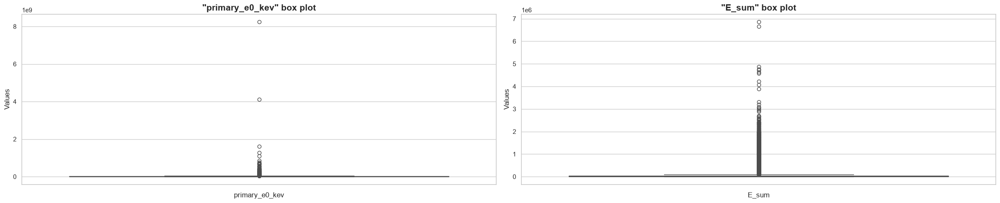

In [59]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=prim_protons_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

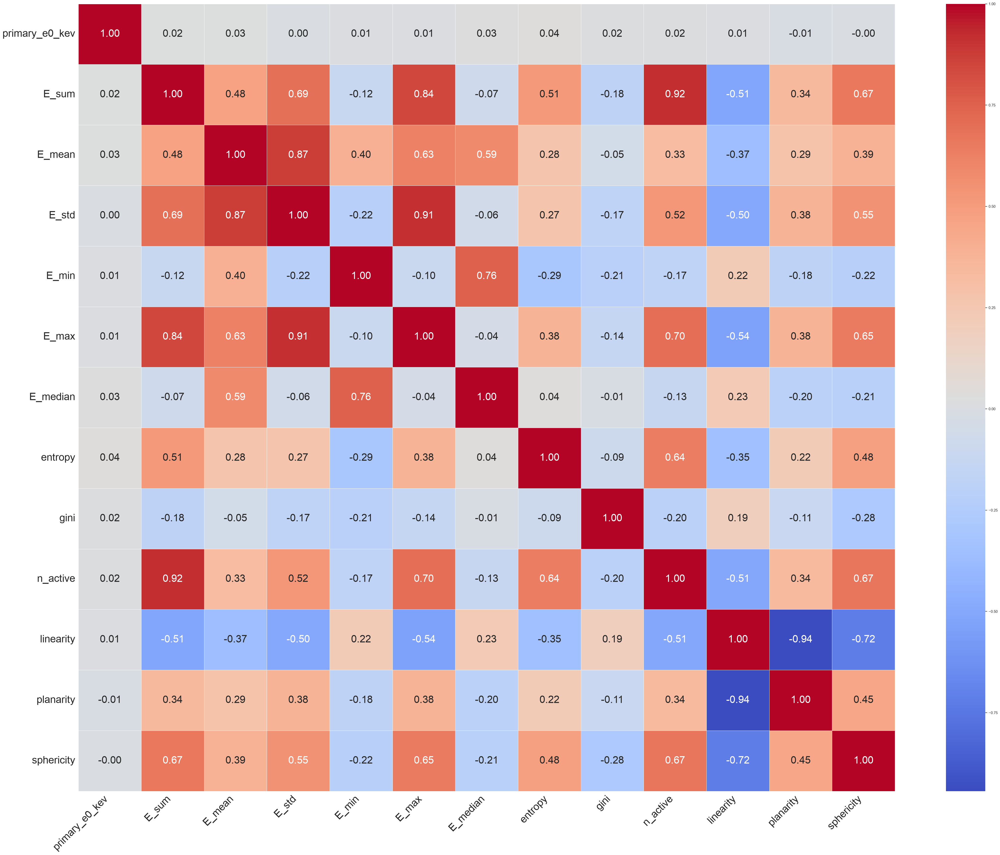

In [60]:
correlation_matrix = (prim_protons_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.8 - Secondary Electrons

In [61]:
url_secondaryelectrons = url_bgdata + "SecondaryElectrons_20260917_164325" + url_ds

sec_electrons = pd.read_csv(url_secondaryelectrons, header=0)
print("Secondary Electrons dataset shape:", sec_electrons.shape)

Secondary Electrons dataset shape: (8730, 53)


In [62]:
sec_electrons.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,8730.000000,8730,8.730000e+03,8730.000000,8.730000e+03,8730.000000,5596.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,4207.000000,4207.000000,8730.000000,8730.000000,8730.000000,8730.0,8730.000000,8730.000000,8730.0,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8.730000e+03,8730.000000,5596.000000,5.596000e+03,5596.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.0,0.0,4.399000e+03,3821.000000,0.0,8730.000000,8730.000000,8730.000000,8730.000000
unique,NaN,5675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,9,9]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7549.997480,NaN,7.102330e+04,5.193013,1.882503e+04,3416.731959,4004.544246,1533.305175,8079.263206,2641.025689,1696.996789,1958.572338,4185.695668,5884.834950,6768.957100,7777.525733,2227.123330,921.965165,0.822189,-0.513743,0.696518,0.066576,5.193013,1.0,0.726780,0.925582,1.0,4.453390,4.524316,4.531566,0.934826,1.737857,1.723576e-01,0.044236,0.877370,9.864356e-02,0.023986,-0.000331,0.002334,-0.004461,1.964719,1.951775,1.975487,5.193013,1.0,NaN,6.573618e-01,0.938277,NaN,1.337801,1.524322,1.762543,6.943357
std,4354.487453,NaN,3.472954e+05,7.485731,3.584759e+04,2446.361892,2757.437493,2393.294834,9026.579182,2585.920609,2366.668818,2396.596784,3110.482699,4459.302203,5675.018020,7955.239721,2667.254928,1382.058198,0.761641,2.737650,0.740537,0.070370,7.485731,0.0,0.278477,0.141175,0.0,3.164482,3.088036,3.125729,1.039555,3.006996,3.628979e-01,0.103146,0.158347,1.390878e-01,0.044241,0.414491,0.423920,0.418627,2.583049,2.520956,2.556336,7.485731,0.0,NaN,3.705610e-01,0.082037,NaN,1.877532,1.995193,4.929341,11.055989
min,1.000000,NaN,6.782900e+01,1.000000,1.767218e+01,17.672180,0.436059,15.007630,17.672180,17.672180,17.123786,17.672180,17.672180,17.672180,17.672180,17.672180,0.000000,0.000000,-0.950679,-2.437490,-0.000000,0.000000,1.000000,1.0,0.103102,0.280662,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.048029,0.000000e+00,0.000000,-0.997437,-0.997245,-0.998362,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-9.309075e-17,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,3772.750000,NaN,3.948792e+03,1.000000,2.565841e+03,1675.736919,2160.197749,88.953033,2321.669592,748.486295,190.692792,311.786930,1730.311901,2219.103336,2288.176357,2316.788752,0.000000,0.000000,0.326688,-2.165888,0.000000,0.000000,1.000000,1.0,0.481975,0.926107,1.0,1.411352,1.692664,1.555264,0.000000,0.000000,0.000000e+00,0.000000,0.826289,1.179852e-16,0.000000,-0.065200,-0.082307,-0.061998,0.000000,0.000000,0.000000,1.000000,1.0,NaN,4.150375e-01,0.919369,NaN,0.000000,0.000000,0.000000,0.000000
50%,7527.500000,NaN,1.523748e+04,2.000000,7.920692e+03,2942.392745,3706.378837,368.184955,6191.609255,1766.339430,716.778541,1054.622765,3557.018776,5266.564152,5838.678692,6143.264525,1264.097559,334.880295,0.701305,-1.435374,0.548684,0.049743,2.000000,1.0,0.803836,1.000000,1.0,4.315964,4.60490

In [63]:
print(f"\n\nThe features of the Secondary Electrons dataset before filtering are {sec_electrons.shape}:")
print(sec_electrons.columns.tolist())

sec_electrons_filtered = sec_electrons[columns_to_analyze]
print(f"\n\nThe features of the Secondary Electrons dataset after filtering are {sec_electrons_filtered.shape}:")
print(sec_electrons_filtered.columns.tolist())



The features of the Secondary Electrons dataset before filtering are (8730, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Secondary Electrons dataset after filtering are (8730, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [64]:
sec_electrons_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,1,1229.921,1229.92095,1229.920950,NaN,1229.92095,1229.92095,1229.920950,-0.000000,0.000000,1,NaN,NaN,NaN
1,2,33281.655,18014.78213,3002.463688,3232.932437,99.87063,8097.93464,1612.863280,1.307841,0.086219,6,0.974142,0.009031,0.016827
2,3,6978.705,6978.70455,6978.704550,NaN,6978.70455,6978.70455,6978.704550,-0.000000,0.000000,1,NaN,NaN,NaN
3,7,81603.552,2336.14219,2336.142190,NaN,2336.14219,2336.14219,2336.142190,-0.000000,0.000000,1,NaN,NaN,NaN
4,8,1655.636,1655.63601,827.818005,790.240272,269.03375,1386.60226,827.818005,0.443785,0.168752,2,1.000000,0.000000,0.000000


In [65]:
print(f"\nThe number of missing values in each column of the filtered Secondary Electrons dataset is:")
sec_electrons_filtered.isnull().sum()


The number of missing values in each column of the filtered Secondary Electrons dataset is:


event_index          0
primary_e0_kev       0
E_sum                0
E_mean               0
E_std             3134
E_min                0
E_max                0
E_median             0
entropy              0
gini                 0
n_active             0
linearity         3134
planarity         3134
sphericity        3134
dtype: int64

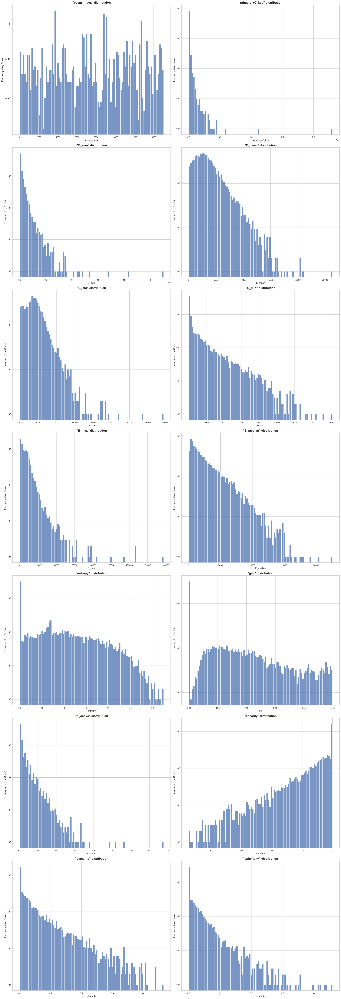

In [66]:
ncols = 2
nrows = (len(sec_electrons_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(sec_electrons_filtered.columns):

    sns.histplot(
        data=sec_electrons_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

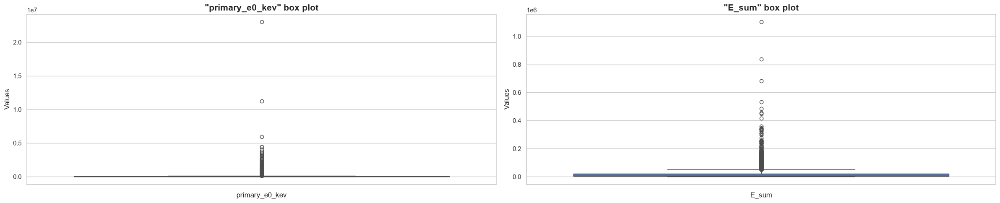

In [67]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=sec_electrons_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

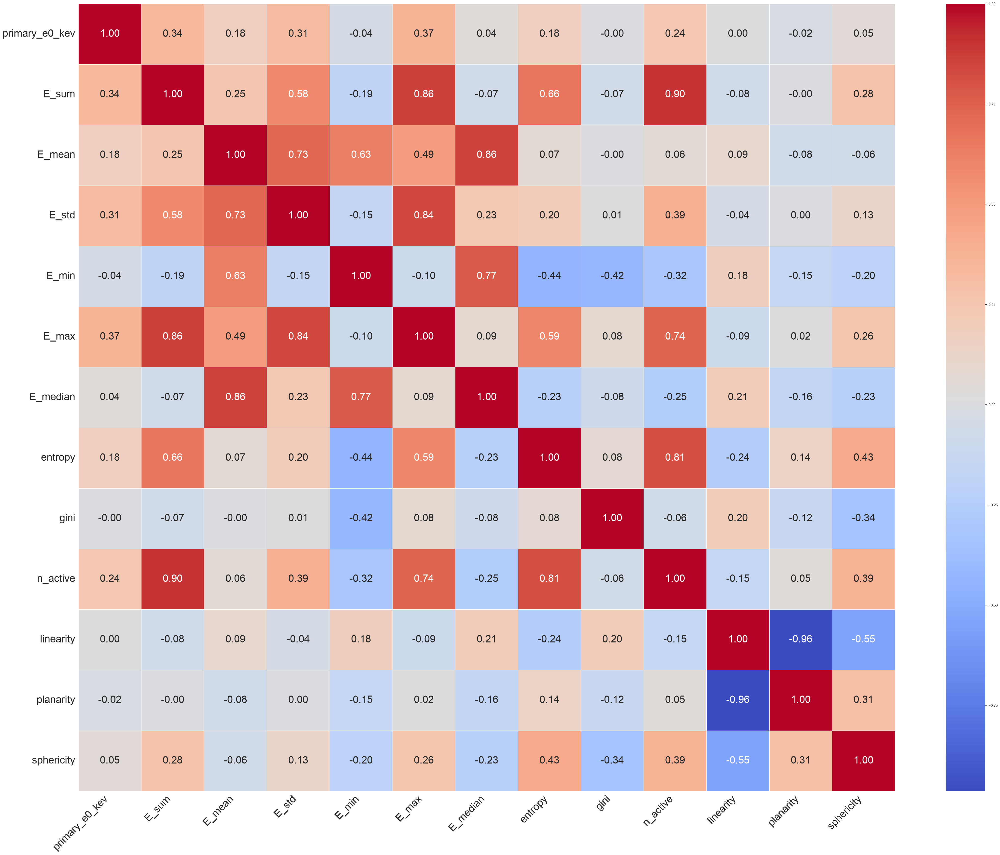

In [68]:
correlation_matrix = (sec_electrons_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.9 - Secondary Positrons

In [69]:
url_secondarypositrons = url_bgdata + "SecondaryPositrons_20260917_164524" + url_ds

sec_positrons = pd.read_csv(url_secondarypositrons, header=0)
print("Secondary Positrons dataset shape:", sec_positrons.shape)

Secondary Positrons dataset shape: (29089, 53)


In [70]:
sec_positrons.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,29089.000000,29089,2.908900e+04,29089.000000,29089.000000,29089.000000,22062.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,17146.000000,17146.000000,29089.000000,29089.000000,29089.000000,29089.0,29089.000000,29089.000000,29089.0,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,22062.000000,22062.000000,22062.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.000000,29089.0,0.0,1.837500e+04,15670.000000,0.0,29089.000000,29089.000000,29089.000000,29089.000000
unique,NaN,20661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,9,9]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,24771.326137,NaN,6.909132e+04,5.798721,18593.039656,2963.285960,3507.693191,1068.450865,7852.650287,2092.351662,1218.626953,1459.217592,3689.018059,5551.596304,6505.227970,7558.458307,2229.800467,864.167879,0.846131,-0.591136,0.797059,0.082909,5.798721,1.0,0.694855,0.917796,1.0,4.470812,4.451601,4.512790,1.143575,2.100388,0.224107,0.054109,0.865327,0.108373,0.026300,-0.000156,-0.001700,0.000600,2.427928,2.435904,2.461377,5.798721,1.0,NaN,6.164052e-01,0.928338,NaN,1.511499,1.722969,1.892159,8.345592
std,14321.659215,NaN,2.700960e+05,7.363655,33424.746827,2277.511759,2538.668393,2092.252473,8519.173569,2374.594397,2086.484338,2140.145968,2958.560482,4262.063142,5492.874205,7661.303283,2470.412286,1233.616633,0.716843,2.484262,0.716892,0.070908,7.363655,0.0,0.268485,0.141341,0.0,3.103915,3.045514,3.092300,1.034832,3.118473,0.396895,0.113578,0.167238,0.146330,0.047215,0.483095,0.483670,0.483822,2.626353,2.600766,2.637858,7.363655,0.0,NaN,3.700661e-01,0.089383,NaN,1.886843,1.990064,4.800649,11.080199
min,1.000000,NaN,1.731428e+01,1.000000,15.321430,15.321430,1.052825,15.004830,15.321430,15.321430,15.321430,15.321430,15.321430,15.321430,15.321430,15.321430,0.000000,0.000000,-0.965746,-2.437485,-0.000000,0.000000,1.000000,1.0,0.092928,0.220014,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.012473,0.000000,0.000000,-0.997592,-0.998555,-0.998245,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-1.057477e-16,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,12364.000000,NaN,3.896166e+03,2.000000,2787.155250,1341.154362,1631.884843,60.214830,2299.343370,503.268720,150.421155,249.311088,1406.526690,2071.721662,2202.231492,2280.303360,81.997480,17.875645,0.369495,-2.181949,0.070634,0.014688,2.000000,1.0,0.462307,0.896069,1.0,1.544629,1.589346,1.616644,0.164512,0.026674,0.000000,0.000000,0.803855,0.004261,0.000000,-0.222853,-0.231089,-0.226799,0.000000,0.000000,0.000000,2.000000,1.0,NaN,3.684828e-01,0.897617,NaN,0.000000,0.000000,0.000000,1.000000
50%,24821.000000,NaN,1.499337e+04,3.000000,8038.825780,2497.328109,3229.244724,210.517610,5968.149360,1199.013000,354.334140,529.692640,2947.096555,4810.577164,5497.561807,5883.358086,1472.702393,368.048395,0.734035,-1.452325,0.676860,0.073380,3.000000,1.0,0.729149,1.000000,1.0,

In [71]:
print(f"\n\nThe features of the Secondary Positrons dataset before filtering are {sec_positrons.shape}:")
print(sec_positrons.columns.tolist())

sec_positrons_filtered = sec_positrons[columns_to_analyze]
print(f"\n\nThe features of the Secondary Positrons dataset after filtering are {sec_positrons_filtered.shape}:")
print(sec_positrons_filtered.columns.tolist())



The features of the Secondary Positrons dataset before filtering are (29089, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Secondary Positrons dataset after filtering are (29089, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [72]:
sec_positrons_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,1,1229.921,1736.72617,347.345234,412.541840,20.05450,1058.30753,171.61342,1.113859,0.103808,5,0.915020,0.078628,0.006353
1,2,33281.655,27131.12904,2466.466276,2826.415970,115.08109,8184.07835,812.80012,1.794314,0.052591,11,0.761386,0.153233,0.085381
2,3,6978.705,8000.70237,1142.957481,2528.277931,27.05079,6867.96474,217.06191,0.622447,0.109230,7,0.941701,0.057113,0.001186
3,4,60826.316,35351.99092,3213.817356,3791.618360,43.06030,11161.31909,1664.34762,1.831288,0.051904,11,0.954786,0.033218,0.011996
4,6,2193.006,2193.00572,1096.502860,1385.987585,116.46164,2076.54408,1096.50286,0.207561,0.223447,2,1.000000,0.000000,0.000000


In [73]:
print(f"\nThe number of missing values in each column of the filtered Secondary Positrons dataset is:")
sec_positrons_filtered.isnull().sum()


The number of missing values in each column of the filtered Secondary Positrons dataset is:


event_index          0
primary_e0_kev       0
E_sum                0
E_mean               0
E_std             7027
E_min                0
E_max                0
E_median             0
entropy              0
gini                 0
n_active             0
linearity         7027
planarity         7027
sphericity        7027
dtype: int64

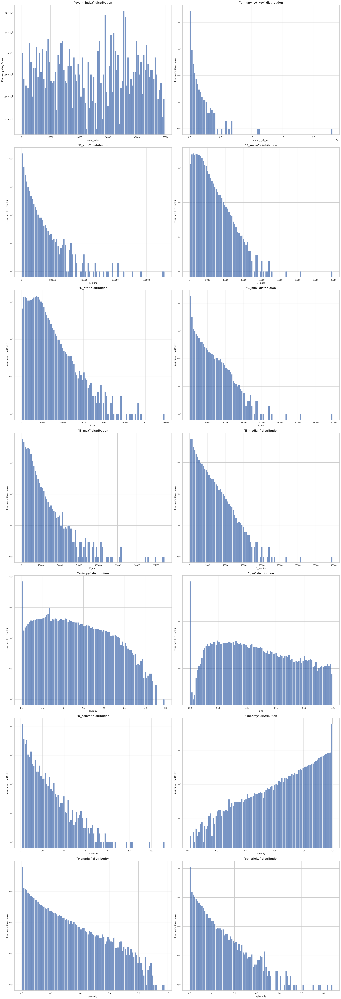

In [74]:
ncols = 2
nrows = (len(sec_positrons_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(sec_positrons_filtered.columns):

    sns.histplot(
        data=sec_positrons_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

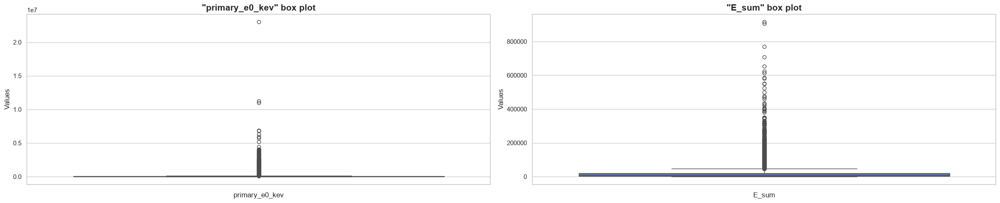

In [75]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=sec_positrons_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

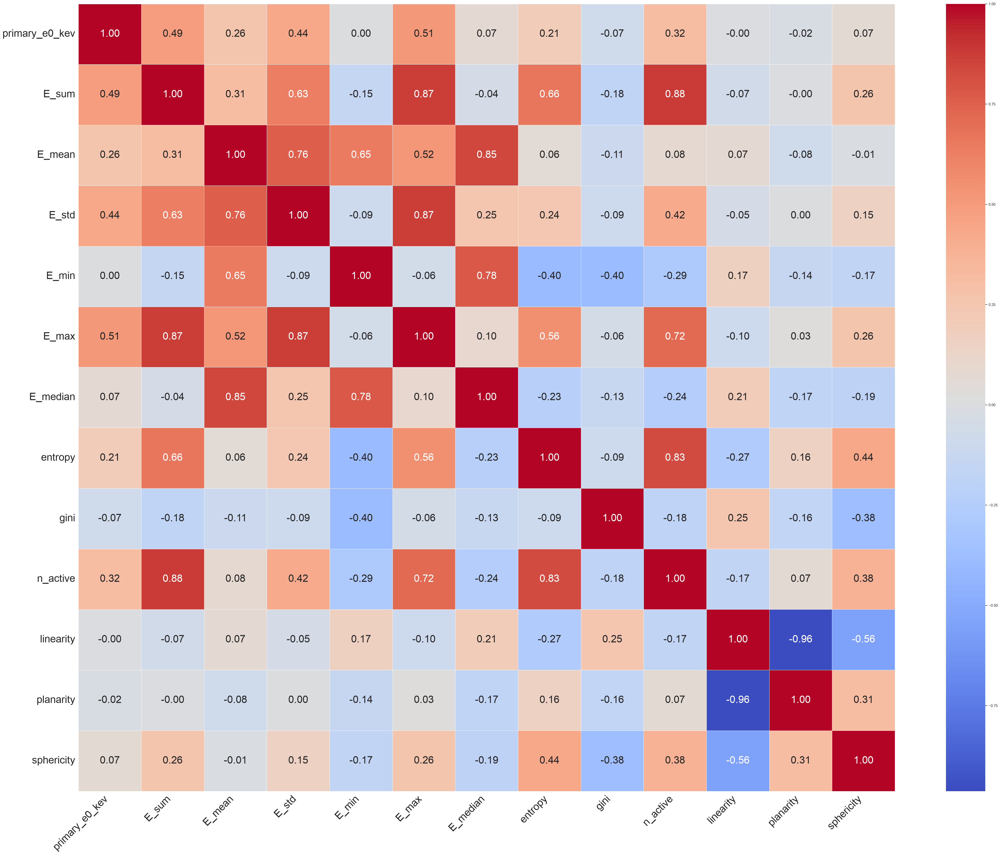

In [76]:
correlation_matrix = (sec_positrons_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.10 - Secondary Protons (Downward)

In [77]:
url_secondaryprotons_downward = url_bgdata + "SecondaryProtonsDownward_20260917_165127" + url_ds

sec_protons_dw = pd.read_csv(url_secondaryprotons_downward, header=0)
print("Secondary Protons (Downward) dataset shape:", sec_protons_dw.shape)

Secondary Protons (Downward) dataset shape: (11060, 53)


In [78]:
sec_protons_dw.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,11060.000000,11060,1.106000e+04,11060.000000,11060.000000,11060.000000,5574.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,4314.000000,4314.000000,11060.000000,11060.000000,11060.000000,11060.0,11060.000000,11060.000000,11060.0,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,1.106000e+04,5574.000000,5574.000000,5.574000e+03,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.000000,11060.0,0.0,4.488000e+03,3980.000000,0.0,11060.000000,11060.000000,11060.000000,11060.000000
unique,NaN,5729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,9,9]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,9599.131284,NaN,3.513561e+05,3.313653,35626.727963,12169.384537,8843.431933,8174.228090,18342.949221,11663.306297,8805.446445,9799.725471,13944.181547,15878.712033,16884.210139,18020.586914,4144.456076,2309.251833,0.256112,-1.295857,0.607149,0.038825,3.313653,1.0,0.733732,0.926021,1.0,4.491205,4.470582,4.901053,0.879147,1.989287,0.061565,1.301195e-02,0.951090,0.041133,7.777560e-03,0.002435,0.003830,-0.001912,1.451537,1.476582,1.206962,3.313653,1.0,NaN,6.173339e-01,0.948874,NaN,0.987342,1.179650,0.628300,3.746589
std,5523.291728,NaN,5.894122e+05,4.023362,44257.199220,11986.948753,8429.788365,11800.371143,19897.117274,12079.920114,11691.614006,11708.695103,13087.624328,14668.057017,16035.050020,18701.020323,6507.789827,4227.179943,0.738396,2.265250,0.717453,0.052807,4.023362,0.0,0.304671,0.141550,0.0,3.122964,3.063360,3.065938,1.136257,3.472392,0.259120,6.231194e-02,0.100699,0.088076,2.558998e-02,0.271564,0.273693,0.281828,2.311704,2.337686,2.083553,4.023362,0.0,NaN,3.099115e-01,0.077525,NaN,1.524915,1.785677,2.165103,6.356843
min,1.000000,NaN,2.150707e+01,1.000000,18.581030,18.581030,2.673295,15.007270,18.581030,18.581030,16.288166,18.581030,18.581030,18.581030,18.581030,18.581030,0.000000,0.000000,-1.967835,-2.436679,-0.000000,0.000000,1.000000,1.0,0.102500,0.269089,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.015919,0.000000,0.000000e+00,-0.999057,-0.999824,-0.999486,0.000000,0.000000,0.000000,1.000000,1.0,NaN,1.451502e-16,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,4836.750000,NaN,8.458233e+03,1.000000,6073.429917,4489.760887,3723.086295,1000.325345,5783.682167,3537.385650,1634.225160,2299.000683,4993.572052,5602.199595,5728.038154,5769.930094,0.000000,0.000000,-0.188660,-2.196490,-0.000000,0.000000,1.000000,1.0,0.432816,0.926370,1.0,1.634790,1.720586,2.000000,0.000000,0.000000,0.000000,0.000000e+00,0.959645,0.000704,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,NaN,5.000000e-01,0.933354,NaN,0.000000,0.000000,0.000000,0.000000
50%,9601.000000,NaN,8.885676e+04,2.000000,21266.319090,8077.229591,5693.848437,3415.323250,12196.027890,7734.172523,4361.524035,5594.615241,9877.597104,11300.696457,11802.381646,12121.287424,57.478980,36.468958,0.154934,-1.811842,0.054570,0.

In [79]:
print(f"\n\nThe features of the Secondary Protons (Downward) dataset before filtering are {sec_protons_dw.shape}:")
print(sec_protons_dw.columns.tolist())

sec_protons_dw_filtered = sec_protons_dw[columns_to_analyze]
print(f"\n\nThe features of the Secondary Protons (Downward) dataset after filtering are {sec_protons_dw_filtered.shape}:")
print(sec_protons_dw_filtered.columns.tolist())



The features of the Secondary Protons (Downward) dataset before filtering are (11060, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Secondary Protons (Downward) dataset after filtering are (11060, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [80]:
sec_protons_dw_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,1,1394.621,1394.62092,1394.620920,NaN,1394.62092,1394.62092,1394.620920,-0.000000,0.000000,1,NaN,NaN,NaN
1,3,27503.931,27503.93060,27503.930600,NaN,27503.93060,27503.93060,27503.930600,-0.000000,0.000000,1,NaN,NaN,NaN
2,8,2323.052,2323.05218,2323.052180,NaN,2323.05218,2323.05218,2323.052180,-0.000000,0.000000,1,NaN,NaN,NaN
3,9,24548.230,24548.22969,24548.229690,NaN,24548.22969,24548.22969,24548.229690,-0.000000,0.000000,1,NaN,NaN,NaN
4,10,590866.655,51057.10406,6382.138008,4713.709181,577.11106,12128.48218,6643.963385,1.800123,0.048567,8,0.985191,0.009322,0.005486


In [81]:
print(f"\nThe number of missing values in each column of the filtered Secondary Protons (Downward) dataset is:")
sec_protons_dw_filtered.isnull().sum()


The number of missing values in each column of the filtered Secondary Protons (Downward) dataset is:


event_index          0
primary_e0_kev       0
E_sum                0
E_mean               0
E_std             5486
E_min                0
E_max                0
E_median             0
entropy              0
gini                 0
n_active             0
linearity         5486
planarity         5486
sphericity        5486
dtype: int64

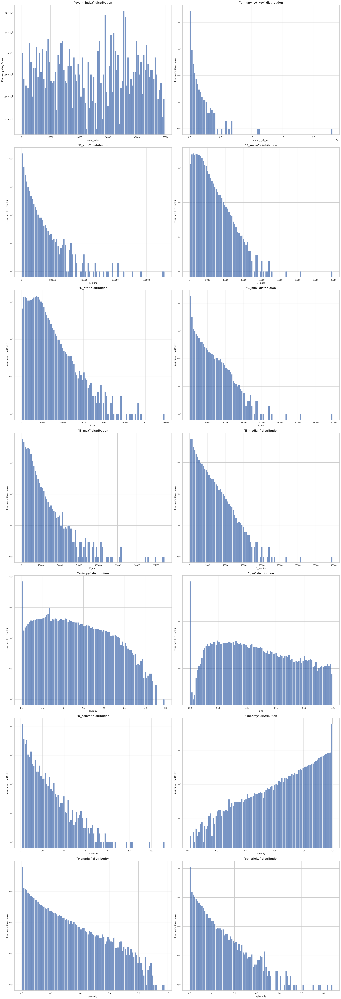

In [82]:
ncols = 2
nrows = (len(sec_positrons_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(sec_positrons_filtered.columns):

    sns.histplot(
        data=sec_positrons_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

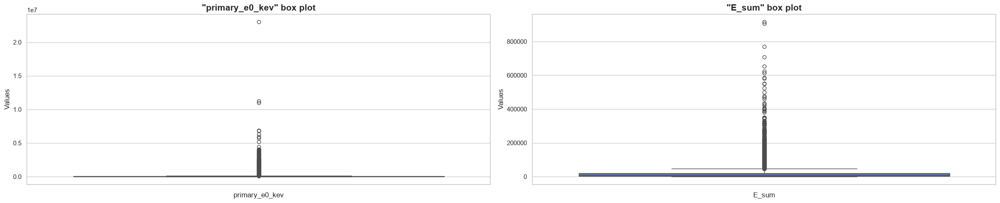

In [83]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=sec_positrons_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

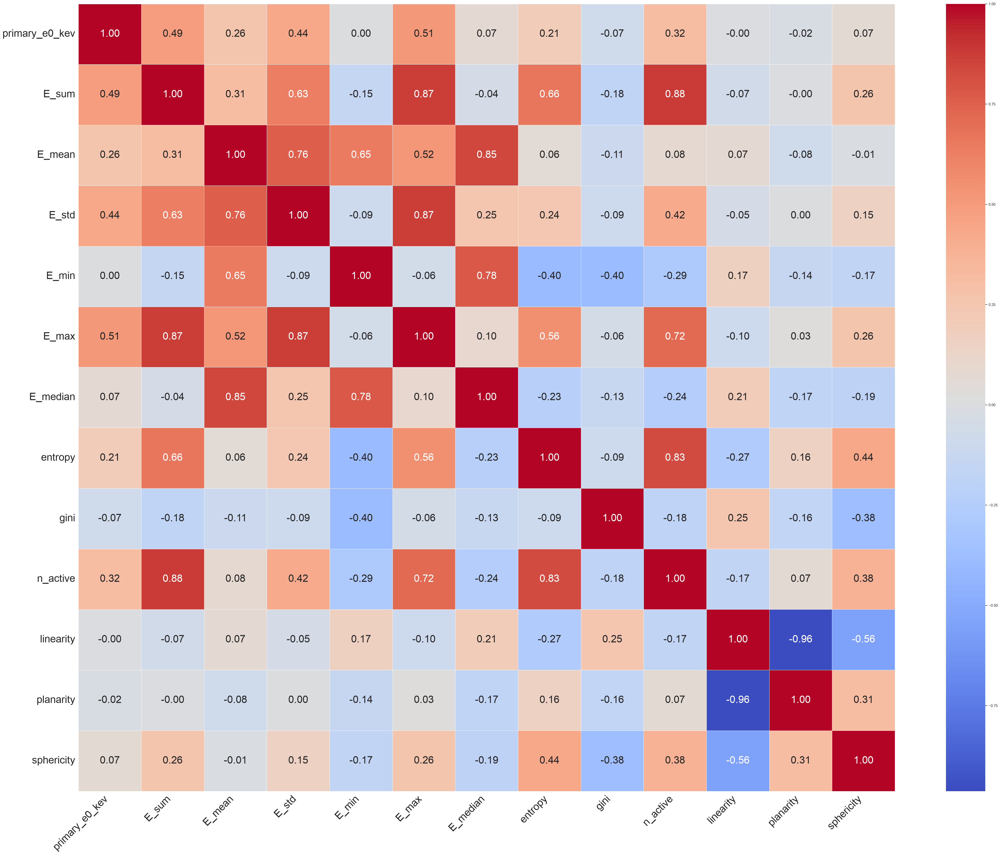

In [84]:
correlation_matrix = (sec_positrons_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

## 1.11 - Secondary Protons (Upward)

In [85]:
url_secondaryprotons_upwards = url_bgdata + "SecondaryProtonsUpward_20260917_165336" + url_ds

sec_protons_up = pd.read_csv(url_secondaryprotons_upwards, header=0)
print("Secondary Protons Upward dataset shape:", sec_protons_up.shape)

Secondary Protons Upward dataset shape: (11901, 53)


In [86]:
sec_protons_up.describe(include="all")

,event_index,pixel_ijk,primary_e0_kev,n_voxels,E_sum,E_mean,E_std,E_min,E_max,E_median,E_p10,E_p25,E_p75,E_p90,E_p95,E_p99,E_iqr,E_mad,E_skew,E_kurt,entropy,gini,n_active,frac_active,frac_top1,frac_top3,eff_E_ge_T,com_x,com_y,com_z,rg,lam1,lam2,lam3,linearity,planarity,sphericity,asym_x,asym_y,asym_z,span_x,span_y,span_z,hits_sum,hits_mean_active,corr_E_hits,D_f,D_f_r2,f_occ,L_max_hops,L_max_metric,N_b,L_skel
count,11901.000000,11901,1.190100e+04,11901.000000,11901.000000,11901.000000,5999.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,4652.000000,4652.000000,11901.000000,11901.000000,11901.000000,11901.0,11901.000000,11901.000000,11901.0,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,5999.000000,5999.000000,5999.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.000000,11901.0,0.0,4.763000e+03,4250.000000,0.0,11901.000000,11901.000000,11901.000000,11901.000000
unique,NaN,6022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"[9,1,0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,9735.772624,NaN,3.527261e+05,3.350559,34920.533484,11850.308694,8665.931572,7929.724261,17963.262569,11356.621451,8539.218624,9514.030075,13582.699283,15475.762306,16507.327607,17656.098572,4068.669208,2294.441940,0.257579,-1.297730,0.618264,0.039115,3.350559,1.0,0.732179,0.920796,1.0,4.517696,4.459485,3.724310,0.873956,1.987447,0.060942,0.013497,0.949799,0.041954,0.008247,0.002878,-0.001720,0.015811,1.212419,1.206705,1.807327,3.350559,1.0,NaN,6.288110e-01,0.954089,NaN,1.032854,1.272719,0.735568,3.717767
std,5659.296461,NaN,5.960183e+05,3.828964,42407.112313,11608.436805,8460.217505,11476.914235,19627.413208,11695.789847,11364.021797,11361.031748,12653.451463,14338.009248,15753.622543,18517.937881,6404.229433,4136.785366,0.723042,2.116799,0.733085,0.053595,3.828964,0.0,0.307672,0.148619,0.0,3.131498,3.081672,3.022802,1.139384,3.555062,0.254111,0.053946,0.101978,0.090111,0.024921,0.276030,0.282430,0.255062,2.036907,2.001712,2.585532,3.828964,0.0,NaN,3.063191e-01,0.071465,NaN,1.561516,1.905071,2.107706,6.074671
min,1.000000,NaN,1.823119e+01,1.000000,18.231190,18.231190,2.008933,15.001350,18.231190,18.231190,15.533984,16.194890,18.231190,18.231190,18.231190,18.231190,0.000000,0.000000,-1.678394,-2.437430,-0.000000,0.000000,1.000000,1.0,0.098220,0.281562,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.049391,0.000000,0.000000,-0.999577,-0.999597,-0.998816,0.000000,0.000000,0.000000,1.000000,1.0,NaN,-9.309075e-17,0.600000,NaN,0.000000,0.000000,0.000000,0.000000
25%,4830.000000,NaN,8.662362e+03,1.000000,6041.927120,4345.303520,3566.183463,1031.104890,5626.800770,3553.996180,1646.260160,2362.767895,4923.865210,5462.524770,5578.224440,5624.349900,0.000000,0.000000,-0.174654,-2.194201,0.000000,0.000000,1.000000,1.0,0.429031,0.914463,1.0,1.673368,1.573706,1.000000,0.000000,0.000000,0.000000,0.000000,0.957542,0.000938,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,NaN,5.000000e-01,0.940573,NaN,0.000000,0.000000,0.000000,0.000000
50%,9702.000000,NaN,8.966571e+04,2.000000,20535.767350,7844.861070,5492.620945,3272.525470,11805.985230,7439.228520,4065.648180,5273.111090,9552.024630,10878.856731,11374.963690,11721.607947,76.244660,43.673610,0.173610,-1.792294,0.076311,0.005132,2.000000,1.0,0.985485,1.00

In [87]:
print(f"\n\nThe features of the Secondary Protons (Upward) dataset before filtering are {sec_protons_up.shape}:")
print(sec_protons_up.columns.tolist())

sec_protons_up_filtered = sec_protons_up[columns_to_analyze]
print(f"\n\nThe features of the Secondary Protons (Upward) dataset after filtering are {sec_protons_up_filtered.shape}:")
print(sec_protons_up_filtered.columns.tolist())



The features of the Secondary Protons (Upward) dataset before filtering are (11901, 53):
['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel']


The features of the Secondary Protons (Upward) dataset after filtering are (11901, 14):
['event_index', 'primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'linearity', 'planarity', 'sphericity']


In [88]:
sec_protons_up_filtered.head(5)

,event_index,primary_e0_kev,E_sum,E_mean,E_std,E_min,E_max,E_median,entropy,gini,n_active,linearity,planarity,sphericity
0,1,1394.621,1394.62092,1394.62092,NaN,1394.62092,1394.62092,1394.620920,-0.00000,0.000000,1,NaN,NaN,NaN
1,3,27503.931,27503.93060,27503.93060,NaN,27503.93060,27503.93060,27503.930600,-0.00000,0.000000,1,NaN,NaN,NaN
2,7,653418.378,2809.17544,2809.17544,NaN,2809.17544,2809.17544,2809.175440,-0.00000,0.000000,1,NaN,NaN,NaN
3,8,2323.052,2323.05218,2323.05218,NaN,2323.05218,2323.05218,2323.052180,-0.00000,0.000000,1,NaN,NaN,NaN
4,10,590866.655,18100.54964,4525.13741,3269.739928,1070.19994,8818.19031,4106.079695,1.18142,0.085945,4,0.558488,0.365582,0.07593


In [89]:
print(f"\nThe number of missing values in each column of the filtered Secondary Protons (Upward) dataset is:")
sec_protons_up_filtered.isnull().sum()


The number of missing values in each column of the filtered Secondary Protons (Upward) dataset is:


event_index          0
primary_e0_kev       0
E_sum                0
E_mean               0
E_std             5902
E_min                0
E_max                0
E_median             0
entropy              0
gini                 0
n_active             0
linearity         5902
planarity         5902
sphericity        5902
dtype: int64

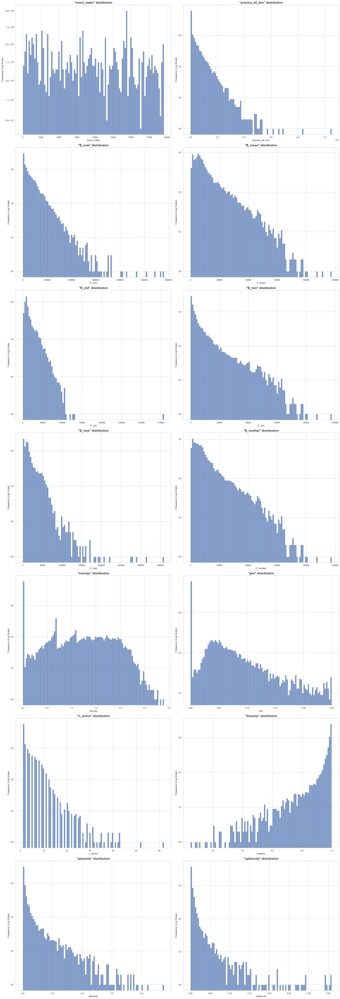

In [90]:
ncols = 2
nrows = (len(sec_protons_up_filtered.columns) + ncols - 1) // ncols
n_bins = 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 10))
axes = axes.flatten()  

for i, column in enumerate(sec_protons_up_filtered.columns):

    sns.histplot(
        data=sec_protons_up_filtered, 
        x=column, 
        bins=n_bins, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_yscale("log")
    axes[i].set_title(f"\"{column}\" distribution", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Frequency (Log Scale)", fontsize=12)

plt.tight_layout()
plt.show()

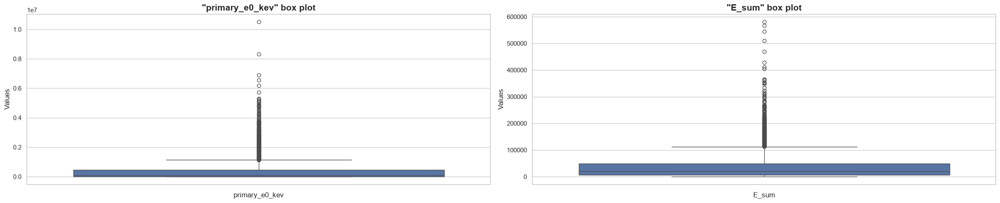

In [91]:
ncols = 2
nrows = (len(colums_box_plot) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, nrows * 5))

for i, column in enumerate(colums_box_plot):
    sns.boxplot(
        data=sec_protons_up_filtered[column], 
        # x=column, 
        ax=axes[i], 
        # color="#2b5c8f",
    )

    axes[i].set_title(f"\"{column}\" box plot", fontsize=15, fontweight="bold")
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)

plt.tight_layout()
plt.show()

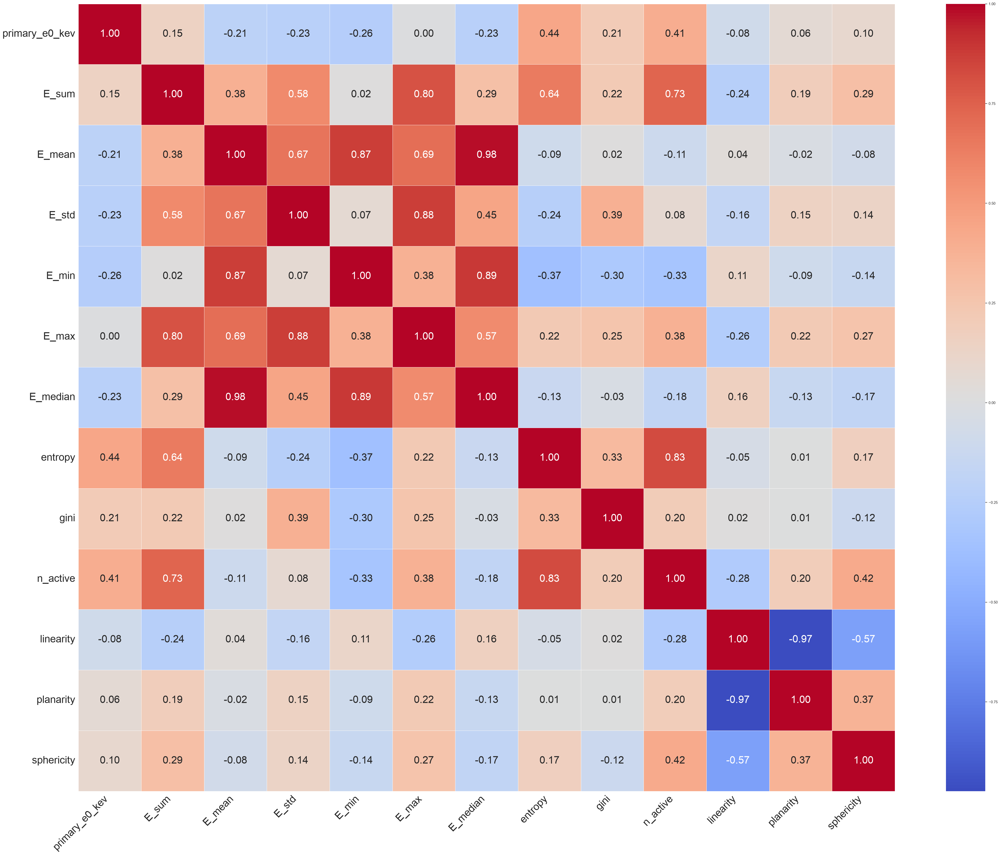

In [92]:
correlation_matrix = (sec_protons_up_filtered.drop(columns=["event_index"])).corr(numeric_only=True)

plt.figure(figsize=(45, 35))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 30},
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=30)
plt.yticks(rotation=0, fontsize=30)
plt.tight_layout()
plt.show()

# 2 - Background comparison

In this section comparisons bewtween different backround dataset are done. 

In [93]:
particle_dict = {
    "Albedo Photons": 1,
    "Atmospheric Neutrons": 2,
    "Cosmic Photons": 3,
    "Primary Alphas": 4,
    "Primary Electrons": 5,
    "Primary Positrons": 6,
    "Primary Protons": 7,
    "Secondary Electrons": 8,
    "Secondary Positrons": 9,
    "Secondary Protons Downward": 10,
    "Secondary Protons Upward": 11
}

## 2.1 - Energy Based Comparison

In [94]:
energy_columns = [
    #'event_index', 
    #'pixel_ijk', 
    'primary_e0_kev',
    #'n_voxels', 
    'E_sum', 
    'E_mean', 
    'E_std', 
    'E_min', 
    'E_max', 
    'E_median', 
    # 'E_p10', 
    # 'E_p25', 
    # 'E_p75', 
    # 'E_p90', 
    # 'E_p95', 
    # 'E_p99', 
    # 'E_iqr', 
    # 'E_mad', 
    # 'E_skew', 
    # 'E_kurt', 
    'entropy', 
    'gini', 
    'n_active', 
    # 'frac_active', 
    # 'frac_top1', 
    # 'frac_top3', 
    # 'eff_E_ge_T',
]

In [95]:
energy_ds = pd.concat([
    albedo_filtered[energy_columns].assign(particle_type=particle_dict["Albedo Photons"]),
    atm_neutrons_filtered[energy_columns].assign(particle_type=particle_dict["Atmospheric Neutrons"]),
    cosmic_pht_filtered[energy_columns].assign(particle_type=particle_dict["Cosmic Photons"]),
    prim_alphas_filtered[energy_columns].assign(particle_type=particle_dict["Primary Alphas"]),
    prim_electrons_filtered[energy_columns].assign(particle_type=particle_dict["Primary Electrons"]),
    prim_positrons_filtered[energy_columns].assign(particle_type=particle_dict["Primary Positrons"]),
    prim_protons_filtered[energy_columns].assign(particle_type=particle_dict["Primary Protons"]),
    sec_electrons_filtered[energy_columns].assign(particle_type=particle_dict["Secondary Electrons"]),
    sec_positrons_filtered[energy_columns].assign(particle_type=particle_dict["Secondary Positrons"]),
    sec_protons_dw_filtered[energy_columns].assign(particle_type=particle_dict["Secondary Protons Downward"]),
    sec_protons_up_filtered[energy_columns].assign(particle_type=particle_dict["Secondary Protons Upward"])
], ignore_index=True)

print("Combined Energy dataset shape:", energy_ds.shape)
print("Combined Energy dataset columns:", energy_ds.columns.tolist())

# check 
print("---Combined Energy dataset particle type qta:---", energy_ds['particle_type'].value_counts())

Combined Energy dataset shape: (324057, 11)
Combined Energy dataset columns: ['primary_e0_kev', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'entropy', 'gini', 'n_active', 'particle_type']
---Combined Energy dataset particle type qta:--- particle_type
3     152860
1      86862
9      29089
7      18461
11     11901
10     11060
8       8730
4       2781
2       2161
5        148
6          4
Name: count, dtype: int64


In [96]:
print("Number of missing values in each column of the combined Energy dataset:")
print(energy_ds.isnull().sum())

print("\n\nCleaning the combined Energy dataset by dropping rows with missing values:")
energy_ds = energy_ds.dropna()

print("\n\nNumber of rows in the cleaned Energy dataset:")
print(energy_ds.shape[0])

Number of missing values in each column of the combined Energy dataset:
primary_e0_kev         0
E_sum                  0
E_mean                 0
E_std             230281
E_min                  0
E_max                  0
E_median               0
entropy                0
gini                   0
n_active               0
particle_type          0
dtype: int64


Cleaning the combined Energy dataset by dropping rows with missing values:


Number of rows in the cleaned Energy dataset:
93776


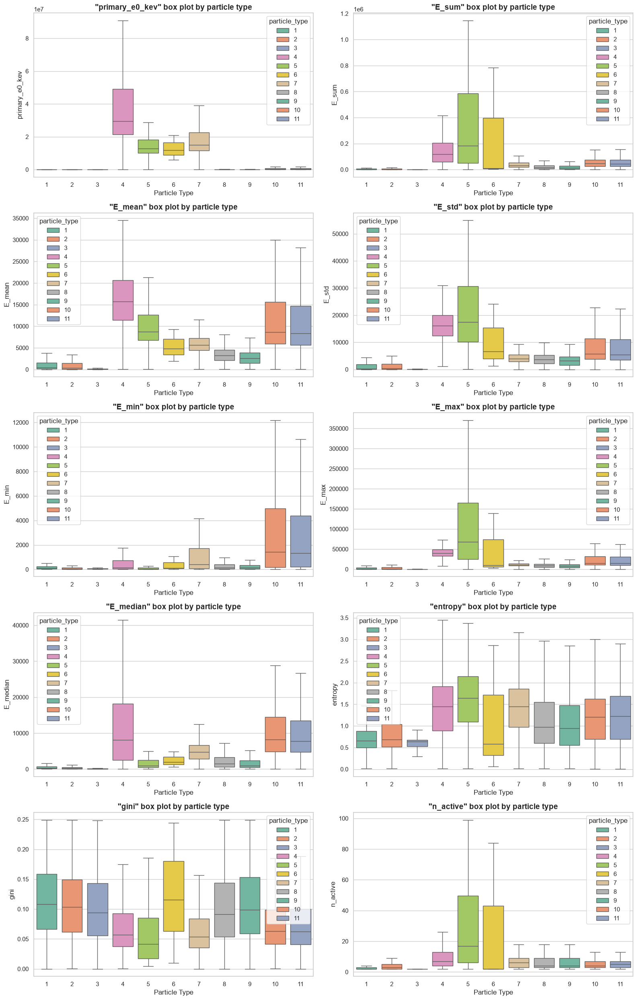

In [97]:
# Compare each energy feature across different particle types using boxplots
ncols = 2
nrows = ((len(energy_columns) -1) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

# particle_names = energy_ds["particle_type"].map()
for i, column in enumerate(energy_columns):
    sns.boxplot(
        data=energy_ds,            
        x="particle_type",         
        y=column,          
        hue="particle_type",    # Color by particle type
        palette="Set2",                
        ax=axes[i],
        showfliers=False        # This will hide the outliers from the boxplot           
    )
    axes[i].set_title(f'"{column}" box plot by particle type', fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Particle Type", fontsize=12)
    axes[i].set_ylabel(column, fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/3252100872.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/3252100872.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/3252100872.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/3252100872.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/3252100872.py:14: UserWarning: Dataset has 0 variance; skipping density estimat

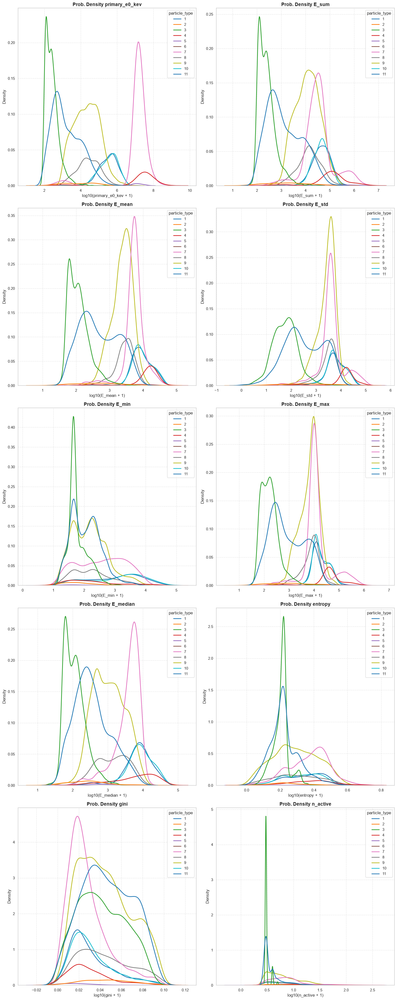

In [130]:
sample = energy_ds.sample(
    n=min(10000, len(energy_ds)),
    random_state=42,
).copy()

sample[energy_columns] = np.log10(sample[energy_columns].clip(lower=0) + 1)

ncols = 2
nrows = (len(energy_columns) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 8), squeeze=False,)
axes = axes.flatten()

for i, col in enumerate(energy_columns):
    sns.kdeplot(
        data=sample.dropna(subset=[col, "particle_type"]),
        x=col,
        hue="particle_type",
        common_norm=True,      # Normalization per particle type
        palette="tab10",
        linewidth=2,
        fill=False,
        ax=axes[i],
    )

    axes[i].set_title(f"Prob. Density {col}", fontsize=14, fontweight="bold",)
    axes[i].set_xlabel(f"log10({col} + 1)")
    axes[i].set_ylabel("Density")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 2.2 - Geometric Based Comparison 

In [99]:
geometric_columns = [
    'com_x', 
    'com_y', 
    'com_z', 
    'rg', 
    'lam1', 
    'lam2', 
    'lam3', 
    'linearity', 
    'planarity', 
    'sphericity', 
    'asym_x', 
    'asym_y', 
    'asym_z', 
    'span_x', 
    'span_y', 
    'span_z', 
]

In [100]:
geometric_ds = pd.concat([
    albedo[geometric_columns].assign(particle_type=particle_dict["Albedo Photons"]),
    atm_neutrons[geometric_columns].assign(particle_type=particle_dict["Atmospheric Neutrons"]),
    cosmic_pht[geometric_columns].assign(particle_type=particle_dict["Cosmic Photons"]),
    prim_alphas[geometric_columns].assign(particle_type=particle_dict["Primary Alphas"]),
    prim_electrons[geometric_columns].assign(particle_type=particle_dict["Primary Electrons"]),
    prim_positrons[geometric_columns].assign(particle_type=particle_dict["Primary Positrons"]),
    prim_protons[geometric_columns].assign(particle_type=particle_dict["Primary Protons"]),
    sec_electrons[geometric_columns].assign(particle_type=particle_dict["Secondary Electrons"]),
    sec_positrons[geometric_columns].assign(particle_type=particle_dict["Secondary Positrons"]),
    sec_protons_dw[geometric_columns].assign(particle_type=particle_dict["Secondary Protons Downward"]),
    sec_protons_up[geometric_columns].assign(particle_type=particle_dict["Secondary Protons Upward"])
], ignore_index=True)

print("Combined Geometric dataset shape:", geometric_ds.shape)
print("Combined Geometric dataset columns:", geometric_ds.columns.tolist())

# check 
print("---Combined geometric dataset particle type qta:---", geometric_ds['particle_type'].value_counts())

Combined Geometric dataset shape: (324057, 17)
Combined Geometric dataset columns: ['com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'particle_type']
---Combined geometric dataset particle type qta:--- particle_type
3     152860
1      86862
9      29089
7      18461
11     11901
10     11060
8       8730
4       2781
2       2161
5        148
6          4
Name: count, dtype: int64


In [101]:
print("Number of missing values in each column of the combined Geometric dataset:")
print(geometric_ds.isnull().sum())

print("\n\nCleaning the combined Geometric dataset by dropping rows with missing values:")
geometric_ds = geometric_ds.dropna()

print("\n\nNumber of rows in the cleaned Geometric dataset:")
print(geometric_ds.shape[0])

Number of missing values in each column of the combined Geometric dataset:
com_x                 0
com_y                 0
com_z                 0
rg                    0
lam1                  0
lam2                  0
lam3                  0
linearity        230281
planarity        230281
sphericity       230281
asym_x                0
asym_y                0
asym_z                0
span_x                0
span_y                0
span_z                0
particle_type         0
dtype: int64


Cleaning the combined Geometric dataset by dropping rows with missing values:


Number of rows in the cleaned Geometric dataset:
93776


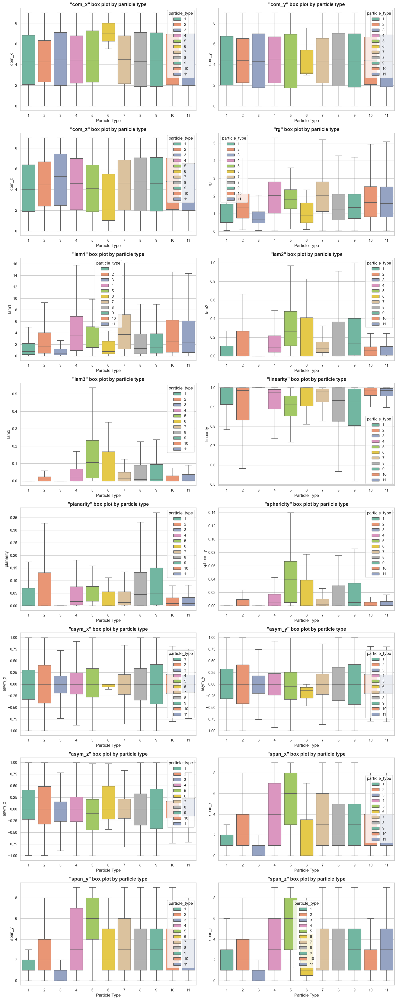

In [102]:
# Compare each energy feature across different particle types using boxplots
ncols = 2
nrows = ((len(geometric_columns) -1) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

# particle_names = energy_ds["particle_type"].map()
for i, column in enumerate(geometric_columns):
    sns.boxplot(
        data=geometric_ds,            
        x="particle_type",         
        y=column,          
        hue="particle_type",    # Color by particle type
        palette="Set2",                
        ax=axes[i],
        showfliers=False        # This will hide the outliers from the boxplot           
    )
    axes[i].set_title(f'"{column}" box plot by particle type', fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Particle Type", fontsize=12)
    axes[i].set_ylabel(column, fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/158712413.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/158712413.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/158712413.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/158712413.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/158712413.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pa

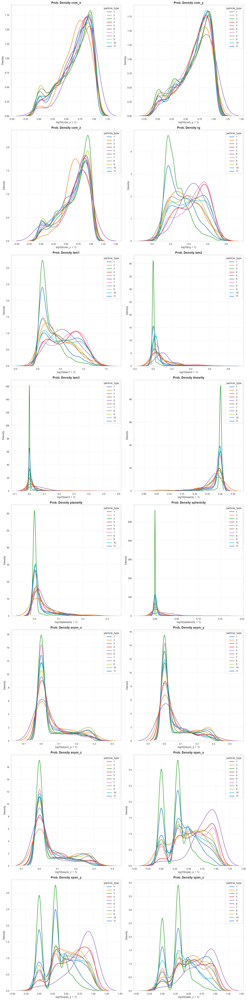

In [103]:
sample = geometric_ds.sample(
    n=min(10000, len(geometric_ds)),
    random_state=42,
).copy()

sample[geometric_columns] = np.log10(sample[geometric_columns].clip(lower=0) + 1)

ncols = 2
nrows = (len(geometric_columns) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 8), squeeze=False,)
axes = axes.flatten()

for i, col in enumerate(geometric_columns):
    sns.kdeplot(
        data=sample.dropna(subset=[col, "particle_type"]),
        x=col,
        hue="particle_type",
        common_norm=False,      # Normalization per particle type
        palette="tab10",
        linewidth=2,
        fill=False,
        ax=axes[i],
    )

    axes[i].set_title(f"Prob. Density {col}", fontsize=14, fontweight="bold",)
    axes[i].set_xlabel(f"log10({col} + 1)")
    axes[i].set_ylabel("Density")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 2.3 - Hits Based Comparison

In [104]:
hits_columns = [
    'hits_sum', 
    'hits_mean_active', 
    'corr_E_hits', 
]


In [105]:
hits_ds = pd.concat([
    albedo[hits_columns].assign(particle_type=particle_dict["Albedo Photons"]),
    atm_neutrons[hits_columns].assign(particle_type=particle_dict["Atmospheric Neutrons"]),
    cosmic_pht[hits_columns].assign(particle_type=particle_dict["Cosmic Photons"]),
    prim_alphas[hits_columns].assign(particle_type=particle_dict["Primary Alphas"]),
    prim_electrons[hits_columns].assign(particle_type=particle_dict["Primary Electrons"]),
    prim_positrons[hits_columns].assign(particle_type=particle_dict["Primary Positrons"]),
    prim_protons[hits_columns].assign(particle_type=particle_dict["Primary Protons"]),
    sec_electrons[hits_columns].assign(particle_type=particle_dict["Secondary Electrons"]),
    sec_positrons[hits_columns].assign(particle_type=particle_dict["Secondary Positrons"]),
    sec_protons_dw[hits_columns].assign(particle_type=particle_dict["Secondary Protons Downward"]),
    sec_protons_up[hits_columns].assign(particle_type=particle_dict["Secondary Protons Upward"])
], ignore_index=True)

print("Combined Hits dataset shape:", hits_ds.shape)
print("Combined Hits dataset columns:", hits_ds.columns.tolist())

# check 
print("---Combined hits dataset particle type qta:---", hits_ds['particle_type'].value_counts())

Combined Hits dataset shape: (324057, 4)
Combined Hits dataset columns: ['hits_sum', 'hits_mean_active', 'corr_E_hits', 'particle_type']
---Combined hits dataset particle type qta:--- particle_type
3     152860
1      86862
9      29089
7      18461
11     11901
10     11060
8       8730
4       2781
2       2161
5        148
6          4
Name: count, dtype: int64


In [106]:
print("Number of missing values in each column of the combined Hits dataset:")
print(hits_ds.isnull().sum())

print("\n\nCleaning the combined Hits dataset by dropping rows with missing values:")
hits_ds = hits_ds.dropna()

print("\n\nNumber of rows in the cleaned Hits dataset:")
print(hits_ds.shape[0])

Number of missing values in each column of the combined Hits dataset:
hits_sum                 0
hits_mean_active         0
corr_E_hits         324057
particle_type            0
dtype: int64


Cleaning the combined Hits dataset by dropping rows with missing values:


Number of rows in the cleaned Hits dataset:
0


In [107]:
# Every value in corr_E_hits has null values, so we will drop this column from the hits_ds dataset and the hits_columns list
hits_columns = [
    'hits_sum', 
    'hits_mean_active',
]

hits_ds = pd.concat([
    albedo[hits_columns].assign(particle_type=particle_dict["Albedo Photons"]),
    atm_neutrons[hits_columns].assign(particle_type=particle_dict["Atmospheric Neutrons"]),
    cosmic_pht[hits_columns].assign(particle_type=particle_dict["Cosmic Photons"]),
    prim_alphas[hits_columns].assign(particle_type=particle_dict["Primary Alphas"]),
    prim_electrons[hits_columns].assign(particle_type=particle_dict["Primary Electrons"]),
    prim_positrons[hits_columns].assign(particle_type=particle_dict["Primary Positrons"]),
    prim_protons[hits_columns].assign(particle_type=particle_dict["Primary Protons"]),
    sec_electrons[hits_columns].assign(particle_type=particle_dict["Secondary Electrons"]),
    sec_positrons[hits_columns].assign(particle_type=particle_dict["Secondary Positrons"]),
    sec_protons_dw[hits_columns].assign(particle_type=particle_dict["Secondary Protons Downward"]),
    sec_protons_up[hits_columns].assign(particle_type=particle_dict["Secondary Protons Upward"])
], ignore_index=True)

print("Combined Hits dataset shape after dropping 'corr_E_hits':", hits_ds.shape)


Combined Hits dataset shape after dropping 'corr_E_hits': (324057, 3)


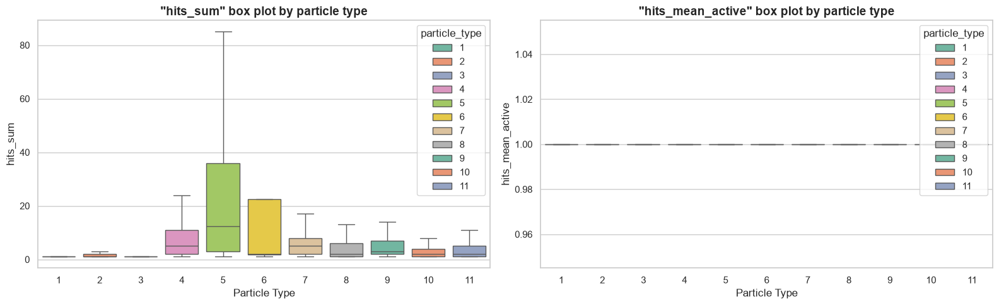

In [108]:
# Compare each hits feature across different particle types using boxplots
ncols = 2
nrows = ((len(hits_columns) -1) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

# particle_names = energy_ds["particle_type"].map()
for i, column in enumerate(hits_columns):
    sns.boxplot(
        data=hits_ds,            
        x="particle_type",         
        y=column,          
        hue="particle_type",    # Color by particle type
        palette="Set2",                
        ax=axes[i],
        showfliers=False        # This will hide the outliers from the boxplot           
    )
    axes[i].set_title(f'"{column}" box plot by particle type', fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Particle Type", fontsize=12)
    axes[i].set_ylabel(column, fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/4015994485.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/j6/n4gj9p255cg0xgxwlflrbx7m0000gn/T/ipykernel_39235/4015994485.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


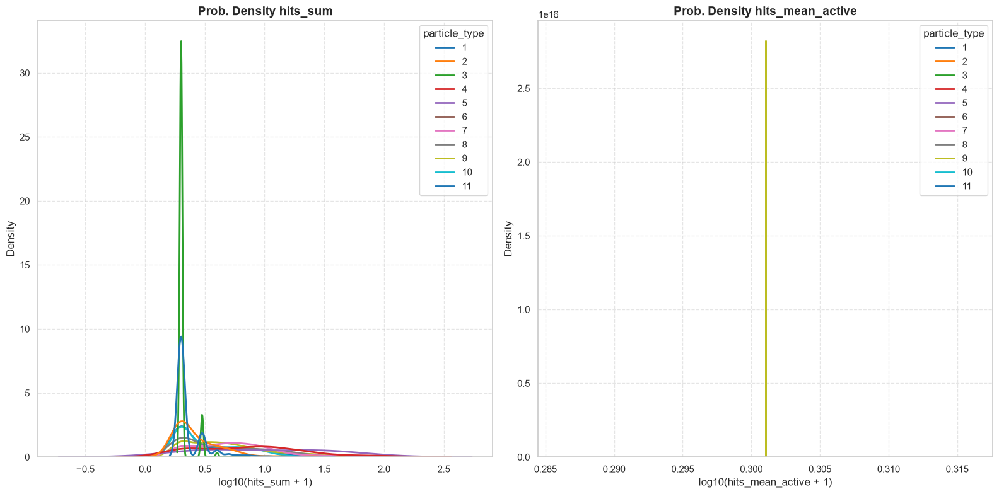

In [109]:
sample = hits_ds.sample(
    n=min(10000, len(hits_ds)),
    random_state=42,
).copy()

sample[hits_columns] = np.log10(sample[hits_columns].clip(lower=0) + 1)

ncols = 2
nrows = (len(hits_columns) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 8), squeeze=False,)
axes = axes.flatten()

for i, col in enumerate(hits_columns):
    sns.kdeplot(
        data=sample.dropna(subset=[col, "particle_type"]),
        x=col,
        hue="particle_type",
        common_norm=False,      # Normalization per particle type
        palette="tab10",
        linewidth=2,
        fill=False,
        ax=axes[i],
    )

    axes[i].set_title(f"Prob. Density {col}", fontsize=14, fontweight="bold",)
    axes[i].set_xlabel(f"log10({col} + 1)")
    axes[i].set_ylabel("Density")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 2.4 - Principal Component Analisys

In [110]:
full_columns = [
    'event_index', 
    'pixel_ijk', 
    'primary_e0_kev',
    'n_voxels', 
    'E_sum', 
    'E_mean', 
    'E_std', 
    'E_min', 
    'E_max', 
    'E_median', 
    'E_p10', 
    'E_p25', 
    'E_p75', 
    'E_p90', 
    'E_p95', 
    'E_p99', 
    'E_iqr', 
    'E_mad', 
    'E_skew', 
    'E_kurt', 
    'entropy', 
    'gini', 
    'n_active', 
    'frac_active', 
    'frac_top1', 
    'frac_top3', 
    'eff_E_ge_T', 
    'com_x', 
    'com_y', 
    'com_z', 
    'rg', 
    'lam1', 
    'lam2', 
    'lam3', 
    'linearity', 
    'planarity', 
    'sphericity', 
    'asym_x', 
    'asym_y', 
    'asym_z', 
    'span_x', 
    'span_y', 
    'span_z', 
    'hits_sum', 
    'hits_mean_active', 
    'corr_E_hits', 
    'D_f', 
    'D_f_r2', 
    'f_occ', 
    'L_max_hops', 
    'L_max_metric', 
    'N_b', 
    'L_skel'
]

In [111]:
full_ds = pd.concat([
    albedo[full_columns].assign(particle_type=particle_dict["Albedo Photons"]),
    atm_neutrons[full_columns].assign(particle_type=particle_dict["Atmospheric Neutrons"]),
    cosmic_pht[full_columns].assign(particle_type=particle_dict["Cosmic Photons"]),
    prim_alphas[full_columns].assign(particle_type=particle_dict["Primary Alphas"]),
    prim_electrons[full_columns].assign(particle_type=particle_dict["Primary Electrons"]),
    prim_positrons[full_columns].assign(particle_type=particle_dict["Primary Positrons"]),
    prim_protons[full_columns].assign(particle_type=particle_dict["Primary Protons"]),
    sec_electrons[full_columns].assign(particle_type=particle_dict["Secondary Electrons"]),
    sec_positrons[full_columns].assign(particle_type=particle_dict["Secondary Positrons"]),
    sec_protons_dw[full_columns].assign(particle_type=particle_dict["Secondary Protons Downward"]),
    sec_protons_up[full_columns].assign(particle_type=particle_dict["Secondary Protons Upward"])
], ignore_index=True)

print("Combined Full dataset shape:", full_ds.shape)
print("Combined Full dataset columns:", full_ds.columns.tolist())

# check 
print("---Combined full dataset particle type qta:---", full_ds['particle_type'].value_counts())

Combined Full dataset shape: (324057, 54)
Combined Full dataset columns: ['event_index', 'pixel_ijk', 'primary_e0_kev', 'n_voxels', 'E_sum', 'E_mean', 'E_std', 'E_min', 'E_max', 'E_median', 'E_p10', 'E_p25', 'E_p75', 'E_p90', 'E_p95', 'E_p99', 'E_iqr', 'E_mad', 'E_skew', 'E_kurt', 'entropy', 'gini', 'n_active', 'frac_active', 'frac_top1', 'frac_top3', 'eff_E_ge_T', 'com_x', 'com_y', 'com_z', 'rg', 'lam1', 'lam2', 'lam3', 'linearity', 'planarity', 'sphericity', 'asym_x', 'asym_y', 'asym_z', 'span_x', 'span_y', 'span_z', 'hits_sum', 'hits_mean_active', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ', 'L_max_hops', 'L_max_metric', 'N_b', 'L_skel', 'particle_type']
---Combined full dataset particle type qta:--- particle_type
3     152860
1      86862
9      29089
7      18461
11     11901
10     11060
8       8730
4       2781
2       2161
5        148
6          4
Name: count, dtype: int64


In [112]:
print("Number of missing values in each column of the full dataset:")
print(full_ds.isnull().sum())

Number of missing values in each column of the full dataset:
event_index              0
pixel_ijk                0
primary_e0_kev           0
n_voxels                 0
E_sum                    0
E_mean                   0
E_std               230281
E_min                    0
E_max                    0
E_median                 0
E_p10                    0
E_p25                    0
E_p75                    0
E_p90                    0
E_p95                    0
E_p99                    0
E_iqr                    0
E_mad                    0
E_skew              267836
E_kurt              267836
entropy                  0
gini                     0
n_active                 0
frac_active              0
frac_top1                0
frac_top3                0
eff_E_ge_T               0
com_x                    0
com_y                    0
com_z                    0
rg                       0
lam1                     0
lam2                     0
lam3                     0
linearity           2

In [113]:
# clean dataset by dropping columns with missing values
colums_to_drop = full_ds.columns[full_ds.isnull().any()].tolist()
print(f"\n\nThe columns with missing values in the full dataset are: {colums_to_drop}")
print("\n\nCleaning the full dataset by dropping columns with missing values:")
full_ds = full_ds.drop(columns=colums_to_drop)
print("Shape of the cleaned full dataset:", full_ds.shape)



The columns with missing values in the full dataset are: ['E_std', 'E_skew', 'E_kurt', 'linearity', 'planarity', 'sphericity', 'corr_E_hits', 'D_f', 'D_f_r2', 'f_occ']


Cleaning the full dataset by dropping columns with missing values:
Shape of the cleaned full dataset: (324057, 44)


X_trans shape: (324057, 41)
Explained variance ratio of each principal component:
[4.01247028e-01 1.67126765e-01 8.67483216e-02 4.36567702e-02
 2.98754415e-02 2.88582016e-02 2.83119501e-02 2.58631460e-02
 2.42388768e-02 2.36197242e-02 2.31537270e-02 2.14186067e-02
 1.90598085e-02 1.61749722e-02 1.40521035e-02 7.42779382e-03
 6.35644228e-03 6.31221471e-03 5.62885115e-03 4.98687557e-03
 3.61919886e-03 3.24837635e-03 3.20643384e-03 1.72147083e-03
 1.24549654e-03 7.37064335e-04 5.73499222e-04 4.77665404e-04
 3.67449355e-04 2.70035475e-04 1.89625815e-04 1.22630756e-04
 6.02464490e-05 2.75427493e-05 1.56431782e-05 1.83480987e-14
 1.17428532e-17 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


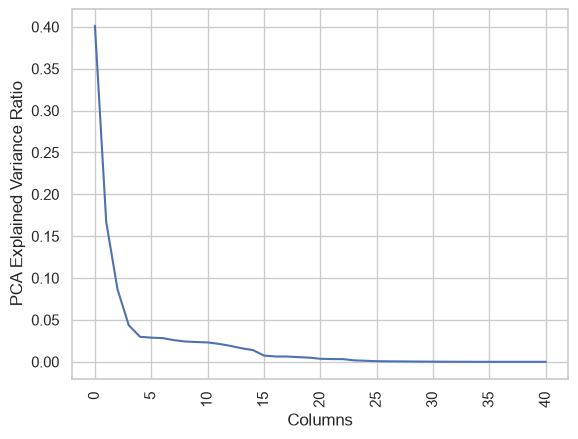

In [118]:
y = full_ds["particle_type"]
X = full_ds.drop(columns=["particle_type", "pixel_ijk", "event_index"])

pca = PCA()
X_scaled = StandardScaler().fit_transform(X)
X_trans = pca.fit_transform(X_scaled)
print("X_trans shape:", X_trans.shape)

print("Explained variance ratio of each principal component:")
print(pca.explained_variance_ratio_)

plt.plot(range(X.shape[1]), pca.explained_variance_ratio_);
plt.xlabel('Columns')
plt.ylabel('PCA Explained Variance Ratio')
plt.xticks(rotation = 90)
plt.show()

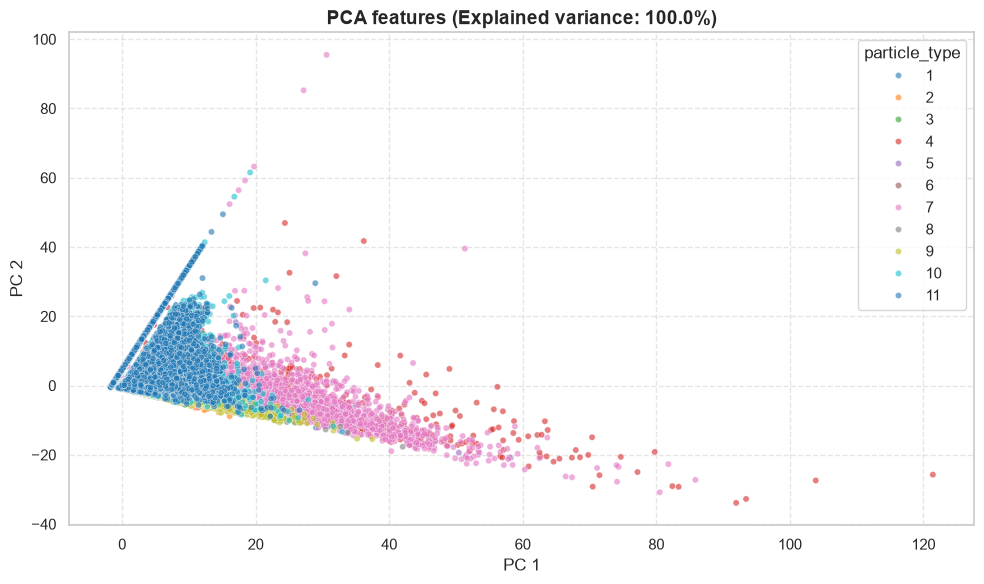

In [119]:
pca_data = pd.DataFrame(
    X_trans[ :, :2],
    columns=["PC1", "PC2"],
    index=X.index,
)

pca_data["particle_type"] = full_ds["particle_type"].values

plt.figure(figsize=(10, 6))


sns.scatterplot(
    data=pca_data,
    x="PC1",
    y="PC2",
    hue="particle_type",
    palette="tab10",
    alpha=0.6,
    s=20,
)

plt.title(
    f"PCA features "
    f"(Explained variance: {pca.explained_variance_ratio_.sum():.1%})",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("PC 1", fontsize=12)
plt.ylabel("PC 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [120]:
loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    columns=["PC1", "PC2"],
    index=X.columns,
).sort_values(by="PC1", ascending=False)

print(loadings)

                           PC1           PC2
L_skel            2.290327e-01 -1.235048e-01
L_max_hops        2.250122e-01 -8.376093e-02
L_max_metric      2.244460e-01 -7.785033e-02
entropy           2.231775e-01 -6.005790e-02
n_voxels          2.183937e-01 -1.215203e-01
n_active          2.183937e-01 -1.215203e-01
hits_sum          2.183937e-01 -1.215203e-01
span_y            2.048267e-01 -7.290752e-02
span_x            2.044463e-01 -7.356273e-02
span_z            2.036447e-01 -7.662460e-02
rg                1.995944e-01 -5.371891e-02
E_p95             1.904279e-01  1.963128e-01
N_b               1.857822e-01 -1.188449e-01
lam3              1.854775e-01 -1.224081e-01
E_p99             1.853398e-01  7.767788e-02
E_p90             1.794310e-01  2.537815e-01
E_sum             1.792423e-01 -5.241237e-02
E_iqr             1.753076e-01  9.992997e-02
lam2              1.744910e-01 -1.083634e-01
E_max             1.726129e-01  1.384623e-02
lam1              1.709397e-01 -5.170721e-02
E_p75     

In [129]:
explained_variances = pca.explained_variance_ratio_

# Sort the explained variance ratios in descending order
sorted_variances = sorted(explained_variances, reverse=True)

# Calculate the cumulative sum of the explained variance ratios
cumulative_variances = np.cumsum(sorted_variances)
print("Cumulative explained variance ratios:", cumulative_variances)

# Find the index i of the first principal component where the cumulative sum exceeds 0.05
cutoff_threshold = 0.05
cutoff_index = np.argmax(cumulative_variances > cutoff_threshold)
print("Used the top {} transformed variables".format(cutoff_index))

# Keep the first i principal components and discard the rest
if cutoff_index > 0:
    X = pca.transform(X_scaled)[:, :cutoff_index+1]

Cumulative explained variance ratios: [0.40124703 0.56837379 0.65512212 0.69877889 0.72865433 0.75751253
 0.78582448 0.81168762 0.8359265  0.85954623 0.88269995 0.90411856
 0.92317837 0.93935334 0.95340544 0.96083324 0.96718968 0.97350189
 0.97913075 0.98411762 0.98773682 0.9909852  0.99419163 0.9959131
 0.9971586  0.99789566 0.99846916 0.99894683 0.99931428 0.99958431
 0.99977394 0.99989657 0.99995681 0.99998436 1.         1.
 1.         1.         1.         1.         1.        ]
Used the top 0 transformed variables
